<a href="https://colab.research.google.com/github/Junahmada/Project-1-Sales-Forecasting/blob/main/Proyek_1_sales_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Preprocessing data



In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

df_store = pd.read_csv('/content/drive/MyDrive/Indonesia AI/Project 1/store5.csv')
df_store

Mounted at /content/drive


,id,date,store_nbr,family,sales,onpromotion,dcoilwtico
0,1452,2013-01-01,5,AUTOMOTIVE,0.000,0,NaN
1,1453,2013-01-01,5,BABY CARE,0.000,0,NaN
2,1454,2013-01-01,5,BEAUTY,0.000,0,NaN
3,1455,2013-01-01,5,BEVERAGES,0.000,0,NaN
4,1456,2013-01-01,5,BOOKS,0.000,0,NaN
...,...,...,...,...,...,...,...
55567,3000586,2017-08-15,5,POULTRY,241.011,1,47.57
55568,3000587,2017-08-15,5,PREPARED FOODS,52.121,0,47.57
55569,3000588,2017-08-15,5,PRODUCE,1357.823,4,47.57
55570,3000589,2017-08-15,5,SCHOOL AND OFFICE SUPPLIES,0.000,0,47.57


In [ ]:
df_store.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55572 entries, 0 to 55571
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           55572 non-null  int64  
 1   date         55572 non-null  object 
 2   store_nbr    55572 non-null  int64  
 3   family       55572 non-null  object 
 4   sales        55572 non-null  float64
 5   onpromotion  55572 non-null  int64  
 6   dcoilwtico   38379 non-null  float64
dtypes: float64(2), int64(3), object(2)
memory usage: 3.0+ MB



#Checking Missing Value & Missing Date

In [ ]:
# Menghitung jumlah missing (NaN) per kolom
missing_per_column = df_store.isna().sum()

# Menampilkan kolom yang memiliki missing values
columns_with_missing = missing_per_column[missing_per_column > 0]

print("Kolom dengan nilai missing (NaN):")
print(columns_with_missing)

# Menampilkan persentase missing per kolom
missing_percentage_per_column = (columns_with_missing / len(df_store)) * 100
print("\nPersentase missing (NaN):")
print(missing_percentage_per_column)


Kolom dengan nilai missing (NaN):
dcoilwtico    17193
dtype: int64

Persentase missing (NaN):
dcoilwtico    30.938242
dtype: float64


In [ ]:
# Pastikan kolom 'date' dalam tipe datetime
df_store['date'] = pd.to_datetime(df_store['date'])

In [ ]:
# Menghitung jumlah nilai 0 pada kolom sales dan onpromotion
zero_sales_count = (df_store['sales'] == 0).sum()
zero_onpromotion_count = (df_store['onpromotion'] == 0).sum()

total_rows = len(df_store)
percent_zero_sales = (zero_sales_count / total_rows) * 100
percent_zero_onpromotion = (zero_onpromotion_count / total_rows) * 100

print(f"Jumlah nilai 0 pada sales: {zero_sales_count}")
print(f"Jumlah nilai 0 pada onpromotion: {zero_onpromotion_count}")
print(f"Persentase nilai 0 pada sales: {percent_zero_sales:.2f}%")
print(f"Persentase nilai 0 pada onpromotion: {percent_zero_onpromotion:.2f}%")

Jumlah nilai 0 pada sales: 12414
Jumlah nilai 0 pada onpromotion: 42357
Persentase nilai 0 pada sales: 22.34%
Persentase nilai 0 pada onpromotion: 76.22%


In [ ]:
# Hitung total sales per family dan ambil top 3
top_3_families = (
    df_store.groupby('family')['sales']
    .sum()
    .sort_values(ascending=False)
    .head(3)
)

print(top_3_families)

family
GROCERY I    5262681.658
BEVERAGES    2533831.000
CLEANING     1667748.000
Name: sales, dtype: float64


#Grocery I

In [ ]:
# Filter hanya data dengan family "GROCERY I"
df_grocery = df_store[df_store["family"] == "GROCERY I"]
df_grocery

,id,date,store_nbr,family,sales,onpromotion,dcoilwtico
12,1464,2013-01-01,5,GROCERY I,0.0,0,NaN
45,3246,2013-01-02,5,GROCERY I,4558.0,0,93.14
78,5028,2013-01-03,5,GROCERY I,3260.0,0,92.97
111,6810,2013-01-04,5,GROCERY I,3085.0,0,93.12
144,8592,2013-01-05,5,GROCERY I,3398.0,0,NaN
...,...,...,...,...,...,...,...
55419,2993442,2017-08-11,5,GROCERY I,2864.0,35,48.81
55452,2995224,2017-08-12,5,GROCERY I,2476.0,31,NaN
55485,2997006,2017-08-13,5,GROCERY I,3141.0,31,NaN
55518,2998788,2017-08-14,5,GROCERY I,2717.0,32,47.59


In [ ]:
df_grocery = df_grocery[['date','store_nbr','family','sales','onpromotion','dcoilwtico']]

In [ ]:
# Buat rentang tanggal lengkap berdasarkan min & max
full_date_range = pd.date_range(start=df_grocery['date'].min(), end=df_grocery['date'].max(), freq='D')

# Cari tanggal yang hilang
missing_dates = full_date_range.difference(df_grocery['date'])
missing_dates

DatetimeIndex(['2013-12-25', '2014-12-25', '2015-12-25', '2016-12-25'], dtype='datetime64[ns]', freq=None)

In [ ]:
# Filter hanya bulan Desember
df_grocery_december = df_grocery[df_grocery['date'].dt.month == 12]
df_grocery_december.head(60)

,date,store_nbr,family,sales,onpromotion,dcoilwtico
11034,2013-12-01,5,GROCERY I,4969.0,0,NaN
11067,2013-12-02,5,GROCERY I,3034.0,0,93.61
11100,2013-12-03,5,GROCERY I,2650.0,0,95.83
11133,2013-12-04,5,GROCERY I,2962.0,0,96.97
11166,2013-12-05,5,GROCERY I,2971.0,0,97.14
11199,2013-12-06,5,GROCERY I,2946.0,0,97.48
11232,2013-12-07,5,GROCERY I,3467.0,0,NaN
11265,2013-12-08,5,GROCERY I,4078.0,0,NaN
11298,2013-12-09,5,GROCERY I,4625.0,0,97.10
11331,2013-12-10,5,GROCERY I,2405.0,0,98.32


In [ ]:
missing_dates[missing_dates.dayofyear == 1]  # Cek Tahun Baru

DatetimeIndex([], dtype='datetime64[ns]', freq=None)

In [ ]:
missing_dates[missing_dates.dayofyear == 364]

DatetimeIndex([], dtype='datetime64[ns]', freq=None)

In [ ]:
# Set index ke 'date' dan reindex dengan full_date_range
df_grocery = df_grocery.set_index('date').reindex(full_date_range).reset_index()

# Pastikan kolom tetap bernama 'date'
df_grocery.rename(columns={'index': 'date'}, inplace=True)

# Isi sales dan onpromotion dengan 0, tetapi dcoilwtico tetap NaN
df_grocery[['sales', 'onpromotion']] = df_grocery[['sales', 'onpromotion']].fillna(0)

In [ ]:
df_grocery

,date,store_nbr,family,sales,onpromotion,dcoilwtico
0,2013-01-01,5.0,GROCERY I,0.0,0.0,NaN
1,2013-01-02,5.0,GROCERY I,4558.0,0.0,93.14
2,2013-01-03,5.0,GROCERY I,3260.0,0.0,92.97
3,2013-01-04,5.0,GROCERY I,3085.0,0.0,93.12
4,2013-01-05,5.0,GROCERY I,3398.0,0.0,NaN
...,...,...,...,...,...,...
1683,2017-08-11,5.0,GROCERY I,2864.0,35.0,48.81
1684,2017-08-12,5.0,GROCERY I,2476.0,31.0,NaN
1685,2017-08-13,5.0,GROCERY I,3141.0,31.0,NaN
1686,2017-08-14,5.0,GROCERY I,2717.0,32.0,47.59


In [ ]:
# Filter hanya bulan Desember
df_december = df_grocery[df_grocery['date'].dt.month == 12]
df_december.head(60)

,date,store_nbr,family,sales,onpromotion,dcoilwtico
334,2013-12-01,5.0,GROCERY I,4969.0,0.0,NaN
335,2013-12-02,5.0,GROCERY I,3034.0,0.0,93.61
336,2013-12-03,5.0,GROCERY I,2650.0,0.0,95.83
337,2013-12-04,5.0,GROCERY I,2962.0,0.0,96.97
338,2013-12-05,5.0,GROCERY I,2971.0,0.0,97.14
339,2013-12-06,5.0,GROCERY I,2946.0,0.0,97.48
340,2013-12-07,5.0,GROCERY I,3467.0,0.0,NaN
341,2013-12-08,5.0,GROCERY I,4078.0,0.0,NaN
342,2013-12-09,5.0,GROCERY I,4625.0,0.0,97.10
343,2013-12-10,5.0,GROCERY I,2405.0,0.0,98.32


In [ ]:
import numpy as np

# Isi missing store_nbr dengan 5 dan family dengan "GROCERY I"
df_grocery['store_nbr'] = df_grocery['store_nbr'].fillna(5).astype(int)
df_grocery['family'] = df_grocery['family'].fillna("GROCERY I")
df_grocery

,date,store_nbr,family,sales,onpromotion,dcoilwtico
0,2013-01-01,5,GROCERY I,0.0,0.0,NaN
1,2013-01-02,5,GROCERY I,4558.0,0.0,93.14
2,2013-01-03,5,GROCERY I,3260.0,0.0,92.97
3,2013-01-04,5,GROCERY I,3085.0,0.0,93.12
4,2013-01-05,5,GROCERY I,3398.0,0.0,NaN
...,...,...,...,...,...,...
1683,2017-08-11,5,GROCERY I,2864.0,35.0,48.81
1684,2017-08-12,5,GROCERY I,2476.0,31.0,NaN
1685,2017-08-13,5,GROCERY I,3141.0,31.0,NaN
1686,2017-08-14,5,GROCERY I,2717.0,32.0,47.59


In [ ]:
# Filter hanya bulan Desember
df_december = df_grocery[df_grocery['date'].dt.month == 12]
df_december.head(60)

,date,store_nbr,family,sales,onpromotion,dcoilwtico
334,2013-12-01,5,GROCERY I,4969.0,0.0,NaN
335,2013-12-02,5,GROCERY I,3034.0,0.0,93.61
336,2013-12-03,5,GROCERY I,2650.0,0.0,95.83
337,2013-12-04,5,GROCERY I,2962.0,0.0,96.97
338,2013-12-05,5,GROCERY I,2971.0,0.0,97.14
339,2013-12-06,5,GROCERY I,2946.0,0.0,97.48
340,2013-12-07,5,GROCERY I,3467.0,0.0,NaN
341,2013-12-08,5,GROCERY I,4078.0,0.0,NaN
342,2013-12-09,5,GROCERY I,4625.0,0.0,97.10
343,2013-12-10,5,GROCERY I,2405.0,0.0,98.32


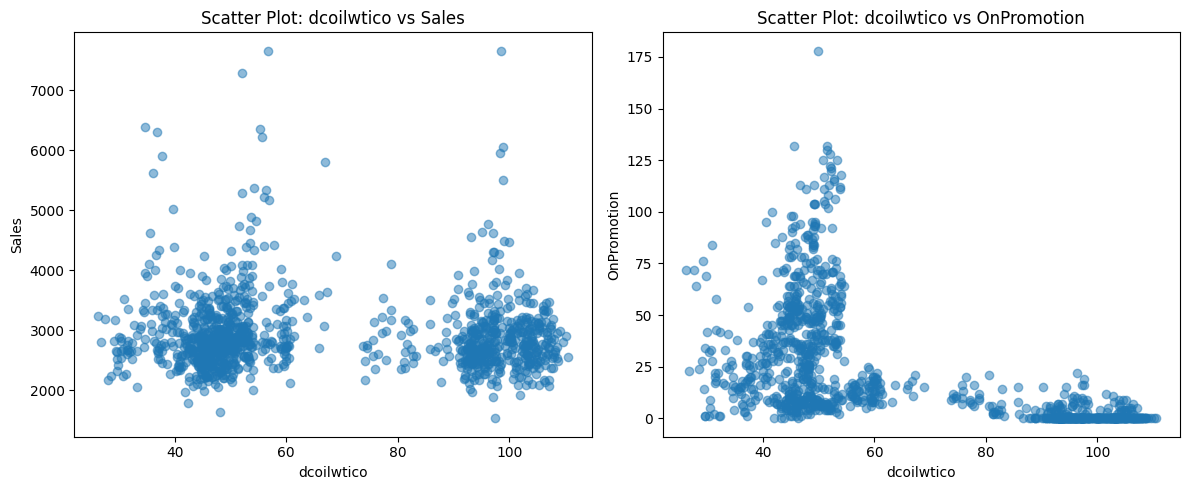

In [ ]:
import matplotlib.pyplot as plt

# Scatter plot dcoilwtico vs sales
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(df_grocery["dcoilwtico"], df_grocery["sales"], alpha=0.5)
plt.xlabel("dcoilwtico")
plt.ylabel("Sales")
plt.title("Scatter Plot: dcoilwtico vs Sales")

# Scatter plot dcoilwtico vs onpromotion
plt.subplot(1, 2, 2)
plt.scatter(df_grocery["dcoilwtico"], df_grocery["onpromotion"], alpha=0.5)
plt.xlabel("dcoilwtico")
plt.ylabel("OnPromotion")
plt.title("Scatter Plot: dcoilwtico vs OnPromotion")

plt.tight_layout()
plt.show()

1. Distribusi tidak membentuk garis lurus, sehingga model linear mungkin gagal menangkap pola.
2. Terdapat lonjakan (non-monotonik) pada onpromotion, yang lebih baik ditangani oleh polynomial.
3. Data sales memiliki variasi tinggi, yang mungkin tidak bisa dijelaskan hanya dengan model linier.

In [ ]:
df_grocery['dcoilwtico_interpolate'] = (
    df_grocery['dcoilwtico']
    .interpolate(method='polynomial', order=2)
    .fillna(method='bfill')  # Mengisi NaN awal dengan nilai pertama yang valid
)

<ipython-input-24-a50e278a32d0>:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method='bfill')  # Mengisi NaN awal dengan nilai pertama yang valid


In [ ]:
# Cek apakah ada NaN setelah interpolasi
print(df_grocery.isna().sum())

date                        0
store_nbr                   0
family                      0
sales                       0
onpromotion                 0
dcoilwtico                525
dcoilwtico_interpolate      0
dtype: int64


In [ ]:
df_grocery

,date,store_nbr,family,sales,onpromotion,dcoilwtico,dcoilwtico_interpolate
0,2013-01-01,5,GROCERY I,0.0,0.0,NaN,93.140000
1,2013-01-02,5,GROCERY I,4558.0,0.0,93.14,93.140000
2,2013-01-03,5,GROCERY I,3260.0,0.0,92.97,92.970000
3,2013-01-04,5,GROCERY I,3085.0,0.0,93.12,93.120000
4,2013-01-05,5,GROCERY I,3398.0,0.0,NaN,93.205338
...,...,...,...,...,...,...,...
1683,2017-08-11,5,GROCERY I,2864.0,35.0,48.81,48.810000
1684,2017-08-12,5,GROCERY I,2476.0,31.0,NaN,48.717426
1685,2017-08-13,5,GROCERY I,3141.0,31.0,NaN,48.020802
1686,2017-08-14,5,GROCERY I,2717.0,32.0,47.59,47.590000


In [ ]:
# # Isi NaN dengan forward fill atau backward fill
# df_store['dcoilwtico_interpolate'].fillna(method='ffill', inplace=True)
# df_store['dcoilwtico_interpolate'].fillna(method='bfill', inplace=True)

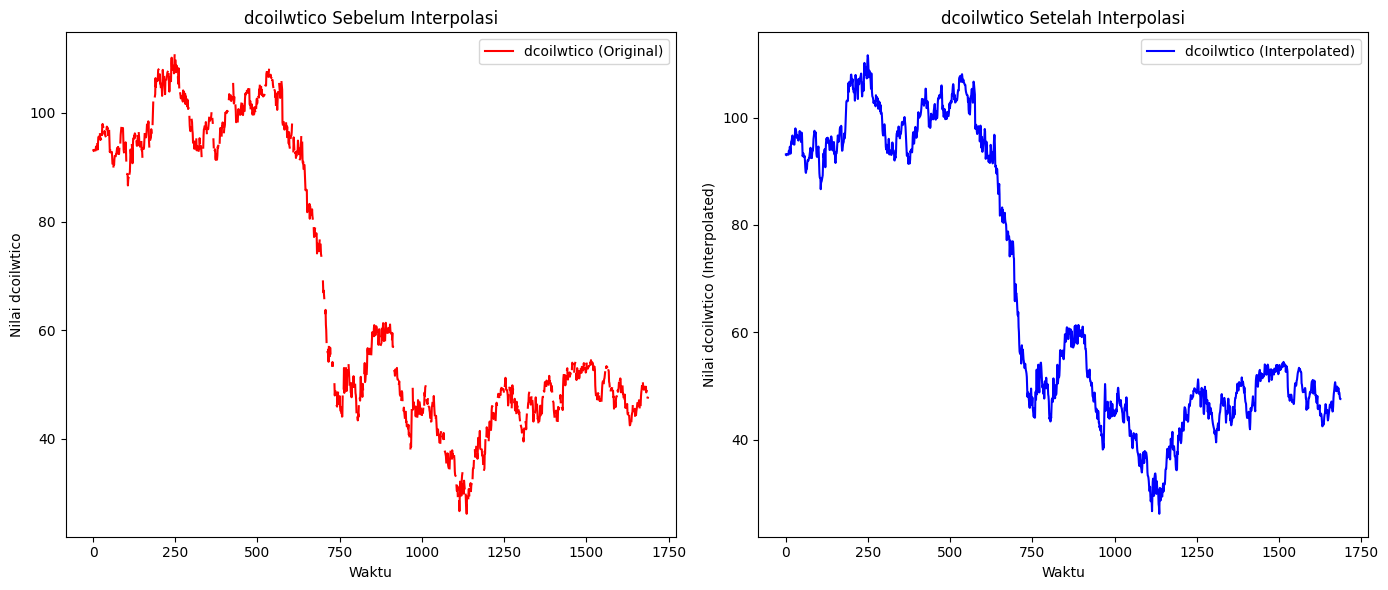

In [ ]:
import matplotlib.pyplot as plt

# Membuat plot perbandingan sebelum dan sesudah interpolasi
plt.figure(figsize=(14, 6))

# Plot dcoilwtico sebelum interpolasi
plt.subplot(1, 2, 1)
plt.plot(df_grocery['dcoilwtico'], label='dcoilwtico (Original)', color='red')
plt.title('dcoilwtico Sebelum Interpolasi')
plt.xlabel('Waktu')
plt.ylabel('Nilai dcoilwtico')
plt.legend()

# Plot dcoilwtico setelah interpolasi
plt.subplot(1, 2, 2)
plt.plot(df_grocery['dcoilwtico_interpolate'], label='dcoilwtico (Interpolated)', color='blue')
plt.title('dcoilwtico Setelah Interpolasi')
plt.xlabel('Waktu')
plt.ylabel('Nilai dcoilwtico (Interpolated)')
plt.legend()

plt.tight_layout()
plt.show()

#Beverages



In [ ]:
# Filter hanya data dengan family "BEVERAGES"
df_beverages = df_store[df_store["family"] == "BEVERAGES"]
df_beverages

,id,date,store_nbr,family,sales,onpromotion,dcoilwtico
3,1455,2013-01-01,5,BEVERAGES,0.0,0,NaN
36,3237,2013-01-02,5,BEVERAGES,947.0,0,93.14
69,5019,2013-01-03,5,BEVERAGES,847.0,0,92.97
102,6801,2013-01-04,5,BEVERAGES,859.0,0,93.12
135,8583,2013-01-05,5,BEVERAGES,912.0,0,NaN
...,...,...,...,...,...,...,...
55410,2993433,2017-08-11,5,BEVERAGES,1717.0,11,48.81
55443,2995215,2017-08-12,5,BEVERAGES,1353.0,6,NaN
55476,2996997,2017-08-13,5,BEVERAGES,1838.0,9,NaN
55509,2998779,2017-08-14,5,BEVERAGES,1771.0,10,47.59


In [ ]:
df_beverages = df_beverages[['date','store_nbr','family','sales','onpromotion','dcoilwtico']]

In [ ]:
# Buat rentang tanggal lengkap berdasarkan min & max
full_date_range = pd.date_range(start=df_beverages['date'].min(), end=df_beverages['date'].max(), freq='D')

# Cari tanggal yang hilang
missing_dates = full_date_range.difference(df_beverages['date'])
missing_dates

DatetimeIndex(['2013-12-25', '2014-12-25', '2015-12-25', '2016-12-25'], dtype='datetime64[ns]', freq=None)

In [ ]:
# Filter hanya bulan Desember
df_beverages_december = df_beverages[df_beverages['date'].dt.month == 12]
df_beverages_december.head(60)

,date,store_nbr,family,sales,onpromotion,dcoilwtico
11025,2013-12-01,5,BEVERAGES,1304.0,0,NaN
11058,2013-12-02,5,BEVERAGES,802.0,0,93.61
11091,2013-12-03,5,BEVERAGES,534.0,0,95.83
11124,2013-12-04,5,BEVERAGES,642.0,0,96.97
11157,2013-12-05,5,BEVERAGES,589.0,0,97.14
11190,2013-12-06,5,BEVERAGES,745.0,0,97.48
11223,2013-12-07,5,BEVERAGES,924.0,0,NaN
11256,2013-12-08,5,BEVERAGES,1047.0,0,NaN
11289,2013-12-09,5,BEVERAGES,637.0,0,97.10
11322,2013-12-10,5,BEVERAGES,584.0,0,98.32


In [ ]:
missing_dates[missing_dates.dayofyear == 1]  # Cek Tahun Baru

DatetimeIndex([], dtype='datetime64[ns]', freq=None)

In [ ]:
missing_dates[missing_dates.dayofyear == 364]

DatetimeIndex([], dtype='datetime64[ns]', freq=None)

In [ ]:
# Set index ke 'date' dan reindex dengan full_date_range
df_beverages = df_beverages.set_index('date').reindex(full_date_range).reset_index()

# Pastikan kolom tetap bernama 'date'
df_beverages.rename(columns={'index': 'date'}, inplace=True)

# Isi sales dan onpromotion dengan 0, tetapi dcoilwtico tetap NaN
df_beverages[['sales', 'onpromotion']] = df_beverages[['sales', 'onpromotion']].fillna(0)

In [ ]:
df_beverages

,date,store_nbr,family,sales,onpromotion,dcoilwtico
0,2013-01-01,5.0,BEVERAGES,0.0,0.0,NaN
1,2013-01-02,5.0,BEVERAGES,947.0,0.0,93.14
2,2013-01-03,5.0,BEVERAGES,847.0,0.0,92.97
3,2013-01-04,5.0,BEVERAGES,859.0,0.0,93.12
4,2013-01-05,5.0,BEVERAGES,912.0,0.0,NaN
...,...,...,...,...,...,...
1683,2017-08-11,5.0,BEVERAGES,1717.0,11.0,48.81
1684,2017-08-12,5.0,BEVERAGES,1353.0,6.0,NaN
1685,2017-08-13,5.0,BEVERAGES,1838.0,9.0,NaN
1686,2017-08-14,5.0,BEVERAGES,1771.0,10.0,47.59


In [ ]:
# Filter hanya bulan Desember
df_december = df_beverages[df_beverages['date'].dt.month == 12]
df_december.head(60)

,date,store_nbr,family,sales,onpromotion,dcoilwtico
334,2013-12-01,5.0,BEVERAGES,1304.0,0.0,NaN
335,2013-12-02,5.0,BEVERAGES,802.0,0.0,93.61
336,2013-12-03,5.0,BEVERAGES,534.0,0.0,95.83
337,2013-12-04,5.0,BEVERAGES,642.0,0.0,96.97
338,2013-12-05,5.0,BEVERAGES,589.0,0.0,97.14
339,2013-12-06,5.0,BEVERAGES,745.0,0.0,97.48
340,2013-12-07,5.0,BEVERAGES,924.0,0.0,NaN
341,2013-12-08,5.0,BEVERAGES,1047.0,0.0,NaN
342,2013-12-09,5.0,BEVERAGES,637.0,0.0,97.10
343,2013-12-10,5.0,BEVERAGES,584.0,0.0,98.32


In [ ]:
import numpy as np

# Isi missing store_nbr dengan 5 dan family dengan "BEVERAGES"
df_beverages['store_nbr'] = df_beverages['store_nbr'].fillna(5).astype(int)
df_beverages['family'] = df_beverages['family'].fillna("BEVERAGES")
df_beverages

,date,store_nbr,family,sales,onpromotion,dcoilwtico
0,2013-01-01,5,BEVERAGES,0.0,0.0,NaN
1,2013-01-02,5,BEVERAGES,947.0,0.0,93.14
2,2013-01-03,5,BEVERAGES,847.0,0.0,92.97
3,2013-01-04,5,BEVERAGES,859.0,0.0,93.12
4,2013-01-05,5,BEVERAGES,912.0,0.0,NaN
...,...,...,...,...,...,...
1683,2017-08-11,5,BEVERAGES,1717.0,11.0,48.81
1684,2017-08-12,5,BEVERAGES,1353.0,6.0,NaN
1685,2017-08-13,5,BEVERAGES,1838.0,9.0,NaN
1686,2017-08-14,5,BEVERAGES,1771.0,10.0,47.59


In [ ]:
# Filter hanya bulan Desember
df_december = df_beverages[df_beverages['date'].dt.month == 12]
df_december.head(60)

,date,store_nbr,family,sales,onpromotion,dcoilwtico
334,2013-12-01,5,BEVERAGES,1304.0,0.0,NaN
335,2013-12-02,5,BEVERAGES,802.0,0.0,93.61
336,2013-12-03,5,BEVERAGES,534.0,0.0,95.83
337,2013-12-04,5,BEVERAGES,642.0,0.0,96.97
338,2013-12-05,5,BEVERAGES,589.0,0.0,97.14
339,2013-12-06,5,BEVERAGES,745.0,0.0,97.48
340,2013-12-07,5,BEVERAGES,924.0,0.0,NaN
341,2013-12-08,5,BEVERAGES,1047.0,0.0,NaN
342,2013-12-09,5,BEVERAGES,637.0,0.0,97.10
343,2013-12-10,5,BEVERAGES,584.0,0.0,98.32


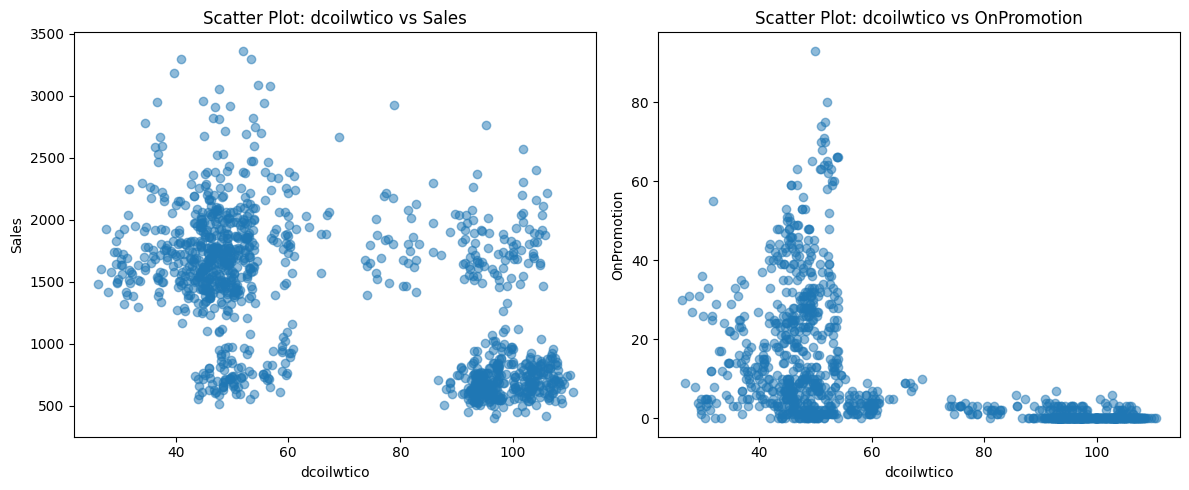

In [ ]:
import matplotlib.pyplot as plt

# Scatter plot dcoilwtico vs sales
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(df_beverages["dcoilwtico"], df_beverages["sales"], alpha=0.5)
plt.xlabel("dcoilwtico")
plt.ylabel("Sales")
plt.title("Scatter Plot: dcoilwtico vs Sales")

# Scatter plot dcoilwtico vs onpromotion
plt.subplot(1, 2, 2)
plt.scatter(df_beverages["dcoilwtico"], df_beverages["onpromotion"], alpha=0.5)
plt.xlabel("dcoilwtico")
plt.ylabel("OnPromotion")
plt.title("Scatter Plot: dcoilwtico vs OnPromotion")

plt.tight_layout()
plt.show()

1. Distribusi tidak membentuk garis lurus, sehingga model linear mungkin gagal
menangkap pola.
2. Terdapat lonjakan (non-monotonik) pada onpromotion, yang lebih baik ditangani oleh polynomial.
3. Data sales memiliki variasi tinggi, yang mungkin tidak bisa dijelaskan hanya dengan model linier.


In [ ]:
df_beverages['dcoilwtico_interpolate'] = (
    df_beverages['dcoilwtico']
    .interpolate(method='polynomial', order=2)
    .fillna(method='bfill')  # Mengisi NaN awal dengan nilai pertama yang valid
)

<ipython-input-41-2fd948574b5d>:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method='bfill')  # Mengisi NaN awal dengan nilai pertama yang valid


In [ ]:
# Cek apakah ada NaN setelah interpolasi
print(df_beverages.isna().sum())

date                        0
store_nbr                   0
family                      0
sales                       0
onpromotion                 0
dcoilwtico                525
dcoilwtico_interpolate      0
dtype: int64


In [ ]:
df_beverages

,date,store_nbr,family,sales,onpromotion,dcoilwtico,dcoilwtico_interpolate
0,2013-01-01,5,BEVERAGES,0.0,0.0,NaN,93.140000
1,2013-01-02,5,BEVERAGES,947.0,0.0,93.14,93.140000
2,2013-01-03,5,BEVERAGES,847.0,0.0,92.97,92.970000
3,2013-01-04,5,BEVERAGES,859.0,0.0,93.12,93.120000
4,2013-01-05,5,BEVERAGES,912.0,0.0,NaN,93.205338
...,...,...,...,...,...,...,...
1683,2017-08-11,5,BEVERAGES,1717.0,11.0,48.81,48.810000
1684,2017-08-12,5,BEVERAGES,1353.0,6.0,NaN,48.717426
1685,2017-08-13,5,BEVERAGES,1838.0,9.0,NaN,48.020802
1686,2017-08-14,5,BEVERAGES,1771.0,10.0,47.59,47.590000


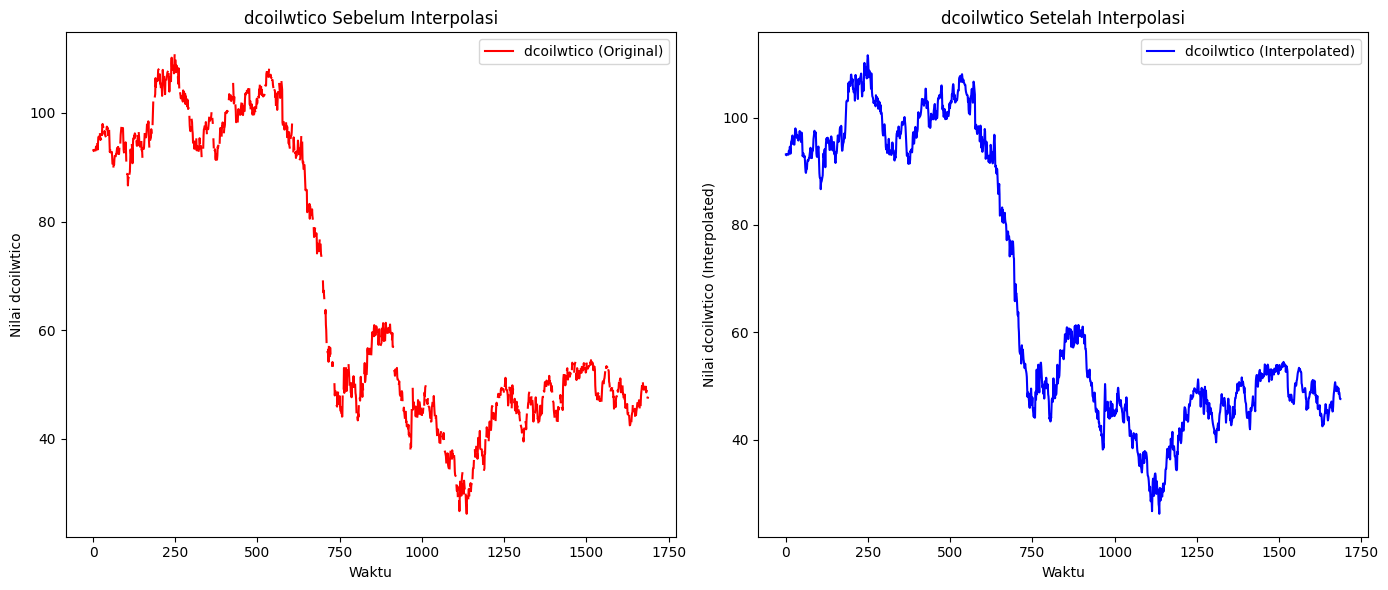

In [ ]:
import matplotlib.pyplot as plt

# Membuat plot perbandingan sebelum dan sesudah interpolasi
plt.figure(figsize=(14, 6))

# Plot dcoilwtico sebelum interpolasi
plt.subplot(1, 2, 1)
plt.plot(df_beverages['dcoilwtico'], label='dcoilwtico (Original)', color='red')
plt.title('dcoilwtico Sebelum Interpolasi')
plt.xlabel('Waktu')
plt.ylabel('Nilai dcoilwtico')
plt.legend()

# Plot dcoilwtico setelah interpolasi
plt.subplot(1, 2, 2)
plt.plot(df_beverages['dcoilwtico_interpolate'], label='dcoilwtico (Interpolated)', color='blue')
plt.title('dcoilwtico Setelah Interpolasi')
plt.xlabel('Waktu')
plt.ylabel('Nilai dcoilwtico (Interpolated)')
plt.legend()

plt.tight_layout()
plt.show()

#Cleaning

In [ ]:
# Filter hanya data dengan family "CLEANING"
df_cleaning = df_store[df_store["family"] == "CLEANING"]
df_cleaning

,id,date,store_nbr,family,sales,onpromotion,dcoilwtico
7,1459,2013-01-01,5,CLEANING,0.0,0,NaN
40,3241,2013-01-02,5,CLEANING,1810.0,0,93.14
73,5023,2013-01-03,5,CLEANING,1305.0,0,92.97
106,6805,2013-01-04,5,CLEANING,1159.0,0,93.12
139,8587,2013-01-05,5,CLEANING,1257.0,0,NaN
...,...,...,...,...,...,...,...
55414,2993437,2017-08-11,5,CLEANING,775.0,16,48.81
55447,2995219,2017-08-12,5,CLEANING,686.0,14,NaN
55480,2997001,2017-08-13,5,CLEANING,927.0,16,NaN
55513,2998783,2017-08-14,5,CLEANING,676.0,10,47.59


In [ ]:
df_cleaning = df_cleaning[['date','store_nbr','family','sales','onpromotion','dcoilwtico']]

In [ ]:
# Buat rentang tanggal lengkap berdasarkan min & max
full_date_range = pd.date_range(start=df_cleaning['date'].min(), end=df_cleaning['date'].max(), freq='D')

# Cari tanggal yang hilang
missing_dates = full_date_range.difference(df_cleaning['date'])
missing_dates

DatetimeIndex(['2013-12-25', '2014-12-25', '2015-12-25', '2016-12-25'], dtype='datetime64[ns]', freq=None)

In [ ]:
# Filter hanya bulan Desember
df_cleaning_december = df_cleaning[df_cleaning['date'].dt.month == 12]
df_cleaning_december.head(60)

,date,store_nbr,family,sales,onpromotion,dcoilwtico
11029,2013-12-01,5,CLEANING,1551.0,0,NaN
11062,2013-12-02,5,CLEANING,906.0,0,93.61
11095,2013-12-03,5,CLEANING,867.0,0,95.83
11128,2013-12-04,5,CLEANING,966.0,0,96.97
11161,2013-12-05,5,CLEANING,911.0,0,97.14
11194,2013-12-06,5,CLEANING,809.0,0,97.48
11227,2013-12-07,5,CLEANING,991.0,0,NaN
11260,2013-12-08,5,CLEANING,1286.0,0,NaN
11293,2013-12-09,5,CLEANING,933.0,0,97.10
11326,2013-12-10,5,CLEANING,718.0,0,98.32


In [ ]:
missing_dates[missing_dates.dayofyear == 1]  # Cek Tahun Baru

DatetimeIndex([], dtype='datetime64[ns]', freq=None)

In [ ]:
missing_dates[missing_dates.dayofyear == 364]

DatetimeIndex([], dtype='datetime64[ns]', freq=None)

In [ ]:
# Set index ke 'date' dan reindex dengan full_date_range
df_cleaning = df_cleaning.set_index('date').reindex(full_date_range).reset_index()

# Pastikan kolom tetap bernama 'date'
df_cleaning.rename(columns={'index': 'date'}, inplace=True)

# Isi sales dan onpromotion dengan 0, tetapi dcoilwtico tetap NaN
df_cleaning[['sales', 'onpromotion']] = df_cleaning[['sales', 'onpromotion']].fillna(0)

In [ ]:
df_cleaning

,date,store_nbr,family,sales,onpromotion,dcoilwtico
0,2013-01-01,5.0,CLEANING,0.0,0.0,NaN
1,2013-01-02,5.0,CLEANING,1810.0,0.0,93.14
2,2013-01-03,5.0,CLEANING,1305.0,0.0,92.97
3,2013-01-04,5.0,CLEANING,1159.0,0.0,93.12
4,2013-01-05,5.0,CLEANING,1257.0,0.0,NaN
...,...,...,...,...,...,...
1683,2017-08-11,5.0,CLEANING,775.0,16.0,48.81
1684,2017-08-12,5.0,CLEANING,686.0,14.0,NaN
1685,2017-08-13,5.0,CLEANING,927.0,16.0,NaN
1686,2017-08-14,5.0,CLEANING,676.0,10.0,47.59


In [ ]:
# Filter hanya bulan Desember
df_december = df_cleaning[df_cleaning['date'].dt.month == 12]
df_december.head(60)

,date,store_nbr,family,sales,onpromotion,dcoilwtico
334,2013-12-01,5.0,CLEANING,1551.0,0.0,NaN
335,2013-12-02,5.0,CLEANING,906.0,0.0,93.61
336,2013-12-03,5.0,CLEANING,867.0,0.0,95.83
337,2013-12-04,5.0,CLEANING,966.0,0.0,96.97
338,2013-12-05,5.0,CLEANING,911.0,0.0,97.14
339,2013-12-06,5.0,CLEANING,809.0,0.0,97.48
340,2013-12-07,5.0,CLEANING,991.0,0.0,NaN
341,2013-12-08,5.0,CLEANING,1286.0,0.0,NaN
342,2013-12-09,5.0,CLEANING,933.0,0.0,97.10
343,2013-12-10,5.0,CLEANING,718.0,0.0,98.32


In [ ]:
import numpy as np

# Isi missing store_nbr dengan 5 dan family dengan "CLEANING"
df_cleaning['store_nbr'] = df_cleaning['store_nbr'].fillna(5).astype(int)
df_cleaning['family'] = df_cleaning['family'].fillna("CLEANING")
df_cleaning

,date,store_nbr,family,sales,onpromotion,dcoilwtico
0,2013-01-01,5,CLEANING,0.0,0.0,NaN
1,2013-01-02,5,CLEANING,1810.0,0.0,93.14
2,2013-01-03,5,CLEANING,1305.0,0.0,92.97
3,2013-01-04,5,CLEANING,1159.0,0.0,93.12
4,2013-01-05,5,CLEANING,1257.0,0.0,NaN
...,...,...,...,...,...,...
1683,2017-08-11,5,CLEANING,775.0,16.0,48.81
1684,2017-08-12,5,CLEANING,686.0,14.0,NaN
1685,2017-08-13,5,CLEANING,927.0,16.0,NaN
1686,2017-08-14,5,CLEANING,676.0,10.0,47.59


In [ ]:
# Filter hanya bulan Desember
df_december = df_cleaning[df_cleaning['date'].dt.month == 12]
df_december.head(60)

,date,store_nbr,family,sales,onpromotion,dcoilwtico
334,2013-12-01,5,CLEANING,1551.0,0.0,NaN
335,2013-12-02,5,CLEANING,906.0,0.0,93.61
336,2013-12-03,5,CLEANING,867.0,0.0,95.83
337,2013-12-04,5,CLEANING,966.0,0.0,96.97
338,2013-12-05,5,CLEANING,911.0,0.0,97.14
339,2013-12-06,5,CLEANING,809.0,0.0,97.48
340,2013-12-07,5,CLEANING,991.0,0.0,NaN
341,2013-12-08,5,CLEANING,1286.0,0.0,NaN
342,2013-12-09,5,CLEANING,933.0,0.0,97.10
343,2013-12-10,5,CLEANING,718.0,0.0,98.32


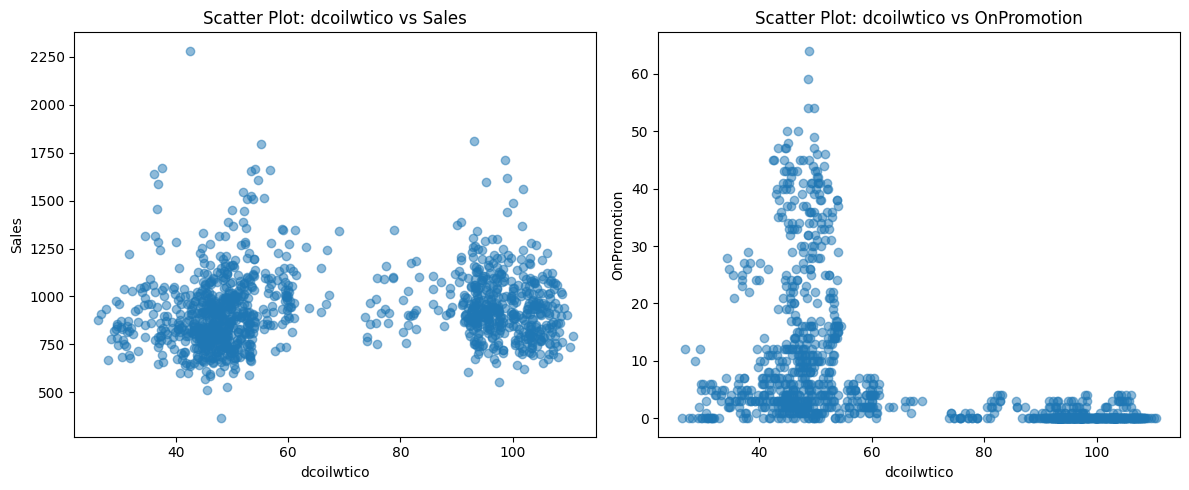

In [ ]:
import matplotlib.pyplot as plt

# Scatter plot dcoilwtico vs sales
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(df_cleaning["dcoilwtico"], df_cleaning["sales"], alpha=0.5)
plt.xlabel("dcoilwtico")
plt.ylabel("Sales")
plt.title("Scatter Plot: dcoilwtico vs Sales")

# Scatter plot dcoilwtico vs onpromotion
plt.subplot(1, 2, 2)
plt.scatter(df_cleaning["dcoilwtico"], df_cleaning["onpromotion"], alpha=0.5)
plt.xlabel("dcoilwtico")
plt.ylabel("OnPromotion")
plt.title("Scatter Plot: dcoilwtico vs OnPromotion")

plt.tight_layout()
plt.show()



1.   Distribusi tidak membentuk garis lurus, sehingga model linear mungkin gagal menangkap pola.
2. Terdapat lonjakan (non-monotonik) pada onpromotion, yang lebih baik ditangani oleh polynomial.
3. Data sales memiliki variasi tinggi, yang mungkin tidak bisa dijelaskan hanya dengan model linier.



In [ ]:
df_cleaning['dcoilwtico_interpolate'] = (
    df_cleaning['dcoilwtico']
    .interpolate(method='polynomial', order=2)
    .fillna(method='bfill')  # Mengisi NaN awal dengan nilai pertama yang valid
)

<ipython-input-57-64e458b1d30c>:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method='bfill')  # Mengisi NaN awal dengan nilai pertama yang valid


In [ ]:
# Cek apakah ada NaN setelah interpolasi
print(df_cleaning.isna().sum())

date                        0
store_nbr                   0
family                      0
sales                       0
onpromotion                 0
dcoilwtico                525
dcoilwtico_interpolate      0
dtype: int64


In [ ]:
df_cleaning

,date,store_nbr,family,sales,onpromotion,dcoilwtico,dcoilwtico_interpolate
0,2013-01-01,5,CLEANING,0.0,0.0,NaN,93.140000
1,2013-01-02,5,CLEANING,1810.0,0.0,93.14,93.140000
2,2013-01-03,5,CLEANING,1305.0,0.0,92.97,92.970000
3,2013-01-04,5,CLEANING,1159.0,0.0,93.12,93.120000
4,2013-01-05,5,CLEANING,1257.0,0.0,NaN,93.205338
...,...,...,...,...,...,...,...
1683,2017-08-11,5,CLEANING,775.0,16.0,48.81,48.810000
1684,2017-08-12,5,CLEANING,686.0,14.0,NaN,48.717426
1685,2017-08-13,5,CLEANING,927.0,16.0,NaN,48.020802
1686,2017-08-14,5,CLEANING,676.0,10.0,47.59,47.590000


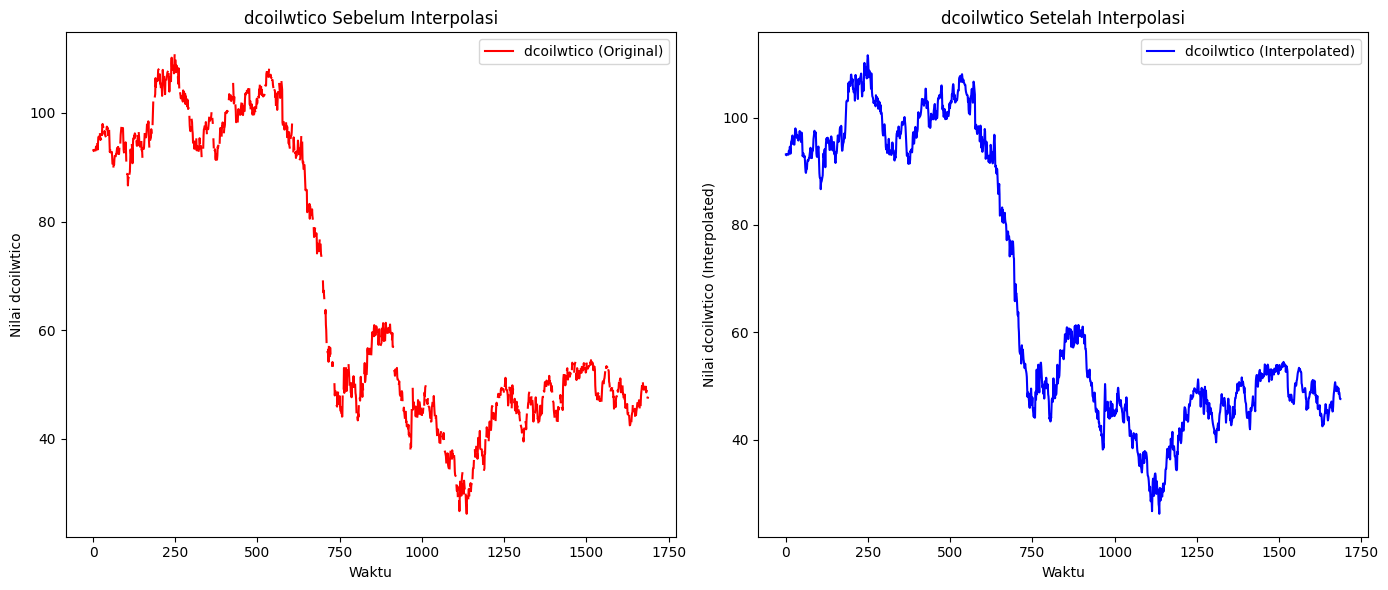

In [ ]:
import matplotlib.pyplot as plt

# Membuat plot perbandingan sebelum dan sesudah interpolasi
plt.figure(figsize=(14, 6))

# Plot dcoilwtico sebelum interpolasi
plt.subplot(1, 2, 1)
plt.plot(df_cleaning['dcoilwtico'], label='dcoilwtico (Original)', color='red')
plt.title('dcoilwtico Sebelum Interpolasi')
plt.xlabel('Waktu')
plt.ylabel('Nilai dcoilwtico')
plt.legend()

# Plot dcoilwtico setelah interpolasi
plt.subplot(1, 2, 2)
plt.plot(df_cleaning['dcoilwtico_interpolate'], label='dcoilwtico (Interpolated)', color='blue')
plt.title('dcoilwtico Setelah Interpolasi')
plt.xlabel('Waktu')
plt.ylabel('Nilai dcoilwtico (Interpolated)')
plt.legend()

plt.tight_layout()
plt.show()

#2. EDA

#Grocery I


In [ ]:
df_grocery

,date,store_nbr,family,sales,onpromotion,dcoilwtico,dcoilwtico_interpolate
0,2013-01-01,5,GROCERY I,0.0,0.0,NaN,93.140000
1,2013-01-02,5,GROCERY I,4558.0,0.0,93.14,93.140000
2,2013-01-03,5,GROCERY I,3260.0,0.0,92.97,92.970000
3,2013-01-04,5,GROCERY I,3085.0,0.0,93.12,93.120000
4,2013-01-05,5,GROCERY I,3398.0,0.0,NaN,93.205338
...,...,...,...,...,...,...,...
1683,2017-08-11,5,GROCERY I,2864.0,35.0,48.81,48.810000
1684,2017-08-12,5,GROCERY I,2476.0,31.0,NaN,48.717426
1685,2017-08-13,5,GROCERY I,3141.0,31.0,NaN,48.020802
1686,2017-08-14,5,GROCERY I,2717.0,32.0,47.59,47.590000


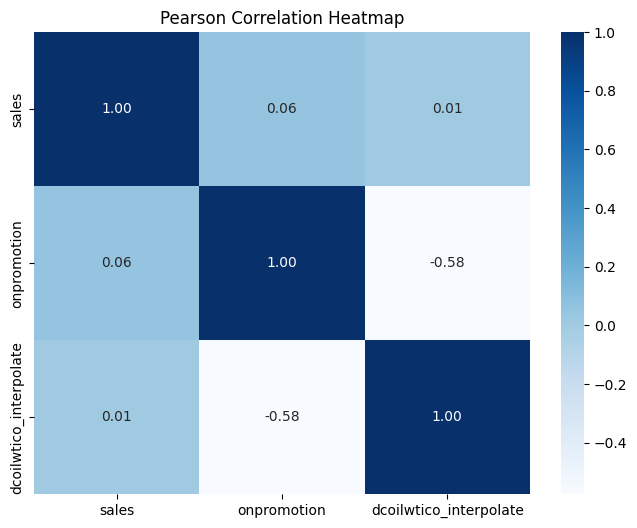

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pastikan kolom 'date' dalam tipe datetime
df_store['date'] = pd.to_datetime(df_store['date'])

# Memilih kolom numerik saja
numeric_cols = ['sales', 'onpromotion', 'dcoilwtico_interpolate']

# Drop missing values (jika ada) agar korelasi dapat dihitung
df_numeric = df_grocery[numeric_cols].dropna()

# Menghitung matriks korelasi Pearson
correlation_matrix = df_numeric.corr(method='pearson')

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt='.2f')
plt.title('Pearson Correlation Heatmap')
plt.show()

#Checking Stationary

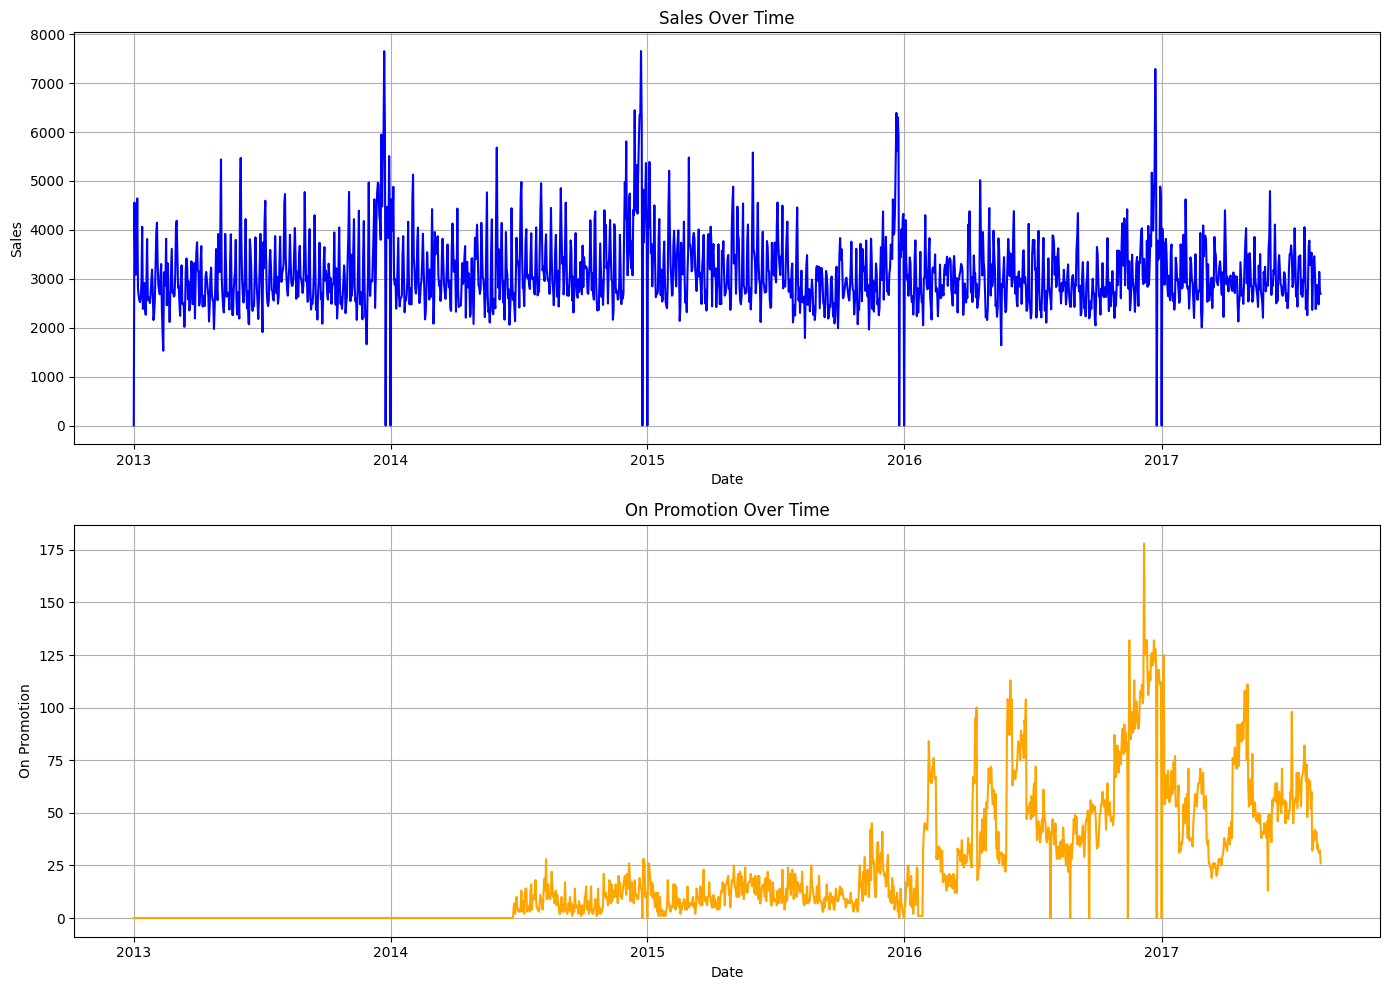

In [ ]:
import matplotlib.pyplot as plt

plt.style.use('default')

plt.figure(figsize=(14, 10), facecolor='white')

# Plot Sales
plt.subplot(2, 1, 1)
plt.plot(df_grocery['date'], df_grocery['sales'], color='blue')
plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)

# Plot On Promotion
plt.subplot(2, 1, 2)
plt.plot(df_grocery['date'], df_grocery['onpromotion'], color='orange')
plt.title("On Promotion Over Time")
plt.xlabel("Date")
plt.ylabel("On Promotion")
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

# Fungsi untuk ADF Test dan menampilkan hasil lengkap
def adf_test(series, series_name="Time Series"):
    result = adfuller(series.dropna())
    print(f"ADF Test for {series_name}:")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print(f"Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value:.4f}")
    if result[1] < 0.05:
        print("=> Data is stationary (reject H0)")
    else:
        print("=> Data is non-stationary (fail to reject H0)")

# Contoh ADF test untuk sales dan onpromotion
adf_test(df_grocery['sales'], "Sales")
adf_test(df_grocery['onpromotion'], "OnPromotion")

ADF Test for Sales:
ADF Statistic: -7.1433
p-value: 0.0000
Critical Values:
   1%: -3.4343
   5%: -2.8633
   10%: -2.5677
=> Data is stationary (reject H0)
ADF Test for OnPromotion:
ADF Statistic: -2.6803
p-value: 0.0775
Critical Values:
   1%: -3.4343
   5%: -2.8633
   10%: -2.5677
=> Data is non-stationary (fail to reject H0)


In [ ]:
df_grocery['onpromotion_diff'] = df_grocery['onpromotion'].diff()

In [ ]:
df_grocery

,date,store_nbr,family,sales,onpromotion,dcoilwtico,dcoilwtico_interpolate,onpromotion_diff
0,2013-01-01,5,GROCERY I,0.0,0.0,NaN,93.140000,NaN
1,2013-01-02,5,GROCERY I,4558.0,0.0,93.14,93.140000,0.0
2,2013-01-03,5,GROCERY I,3260.0,0.0,92.97,92.970000,0.0
3,2013-01-04,5,GROCERY I,3085.0,0.0,93.12,93.120000,0.0
4,2013-01-05,5,GROCERY I,3398.0,0.0,NaN,93.205338,0.0
...,...,...,...,...,...,...,...,...
1683,2017-08-11,5,GROCERY I,2864.0,35.0,48.81,48.810000,2.0
1684,2017-08-12,5,GROCERY I,2476.0,31.0,NaN,48.717426,-4.0
1685,2017-08-13,5,GROCERY I,3141.0,31.0,NaN,48.020802,0.0
1686,2017-08-14,5,GROCERY I,2717.0,32.0,47.59,47.590000,1.0


In [ ]:
# Uji ADF untuk mengecek stasioneritas
result = adfuller(df_grocery['onpromotion_diff'].dropna())

# Print hasil ADF Test
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

# Jika p-value > 0.05, berarti tidak stasioner
if result[1] > 0.05:
    print("Data tidak stasioner, perlu differencing.")
else:
    print("Data sudah stasioner.")

ADF Statistic: -9.669167854280806
p-value: 1.2907189853224762e-16
Data sudah stasioner.


In [ ]:
# Buat rentang tanggal lengkap berdasarkan min & max
full_date_range = pd.date_range(start=df_grocery['date'].min(), end=df_grocery['date'].max(), freq='D')

# Cari tanggal yang hilang
missing_dates = full_date_range.difference(df_grocery['date'])
missing_dates

DatetimeIndex([], dtype='datetime64[ns]', freq='D')

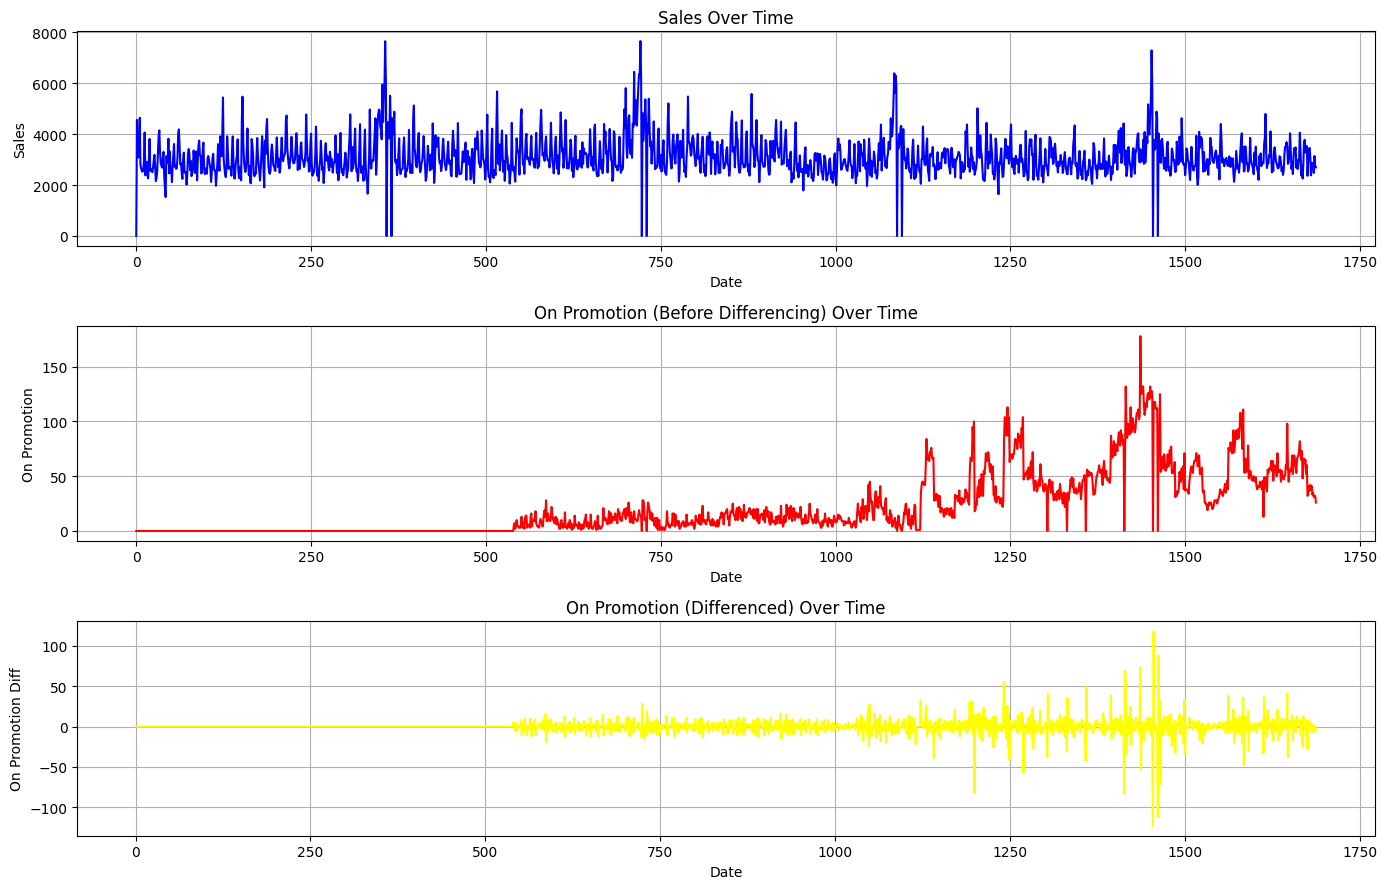

In [ ]:
plt.figure(figsize=(14, 9))

# Plot Sales
plt.subplot(3, 1, 1)
plt.plot(df_grocery.index, df_grocery['sales'], color='blue')
plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)

# Plot On Promotion (Before Differencing)
plt.subplot(3, 1, 2)
plt.plot(df_grocery.index, df_grocery['onpromotion'], color='red')
plt.title("On Promotion (Before Differencing) Over Time")
plt.xlabel("Date")
plt.ylabel("On Promotion")
plt.grid(True)

# Plot On Promotion (Differenced)
plt.subplot(3, 1, 3)
plt.plot(df_grocery.index, df_grocery['onpromotion_diff'], color='yellow')
plt.title("On Promotion (Differenced) Over Time")
plt.xlabel("Date")
plt.ylabel("On Promotion Diff")
plt.grid(True)

plt.tight_layout()
plt.show()

#Plot ACF dan PACF

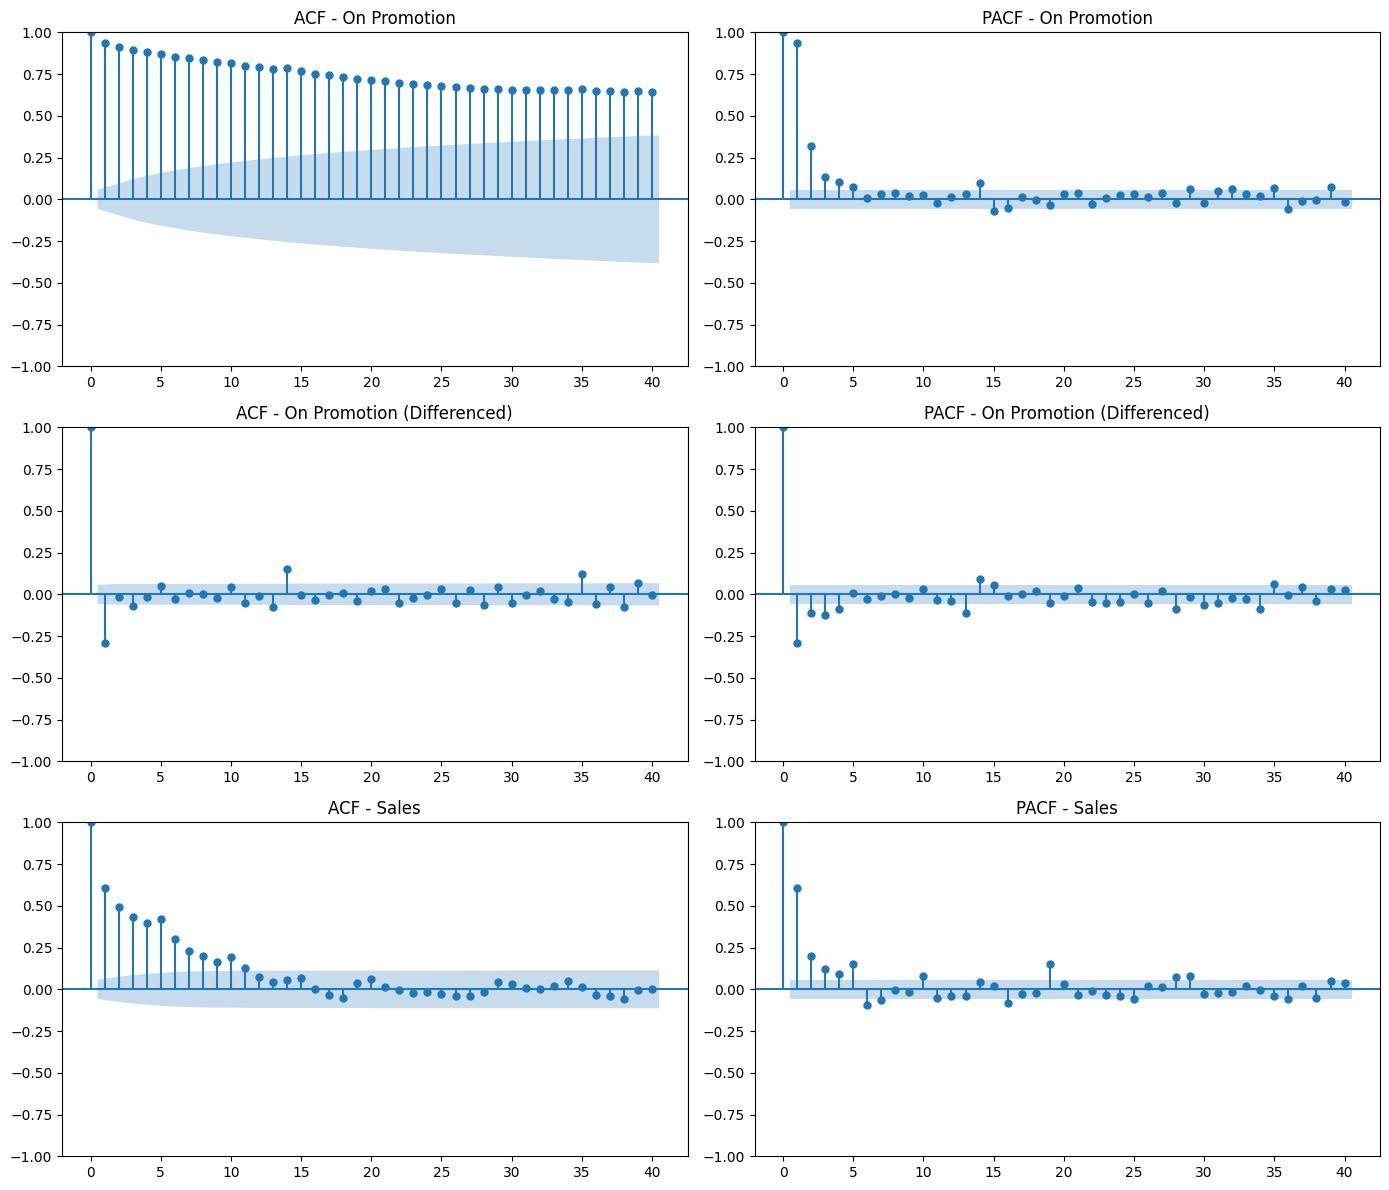

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Pastikan tanggal dalam format datetime
df_grocery['date'] = pd.to_datetime(df_grocery['date'])
df_grocery.set_index('date', inplace=True)

# Lakukan differencing untuk onpromotion
df_grocery['onpromotion_diff'] = df_grocery['onpromotion'].diff()

# Drop NaN akibat differencing
df_grocery.dropna(inplace=True)


fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# ACF & PACF On Promotion (Sebelum Differencing)
plot_acf(df_grocery['onpromotion'], lags=40, ax=axes[0, 0])
axes[0, 0].set_title("ACF - On Promotion")

plot_pacf(df_grocery['onpromotion'], lags=40, ax=axes[0, 1])
axes[0, 1].set_title("PACF - On Promotion")

# ACF & PACF On Promotion (Setelah Differencing)
plot_acf(df_grocery['onpromotion_diff'], lags=40, ax=axes[1, 0])
axes[1, 0].set_title("ACF - On Promotion (Differenced)")

plot_pacf(df_grocery['onpromotion_diff'], lags=40, ax=axes[1, 1])
axes[1, 1].set_title("PACF - On Promotion (Differenced)")

# ACF & PACF Sales
plot_acf(df_grocery['sales'], lags=40, ax=axes[2, 0])
axes[2, 0].set_title("ACF - Sales")

plot_pacf(df_grocery['sales'], lags=40, ax=axes[2, 1])
axes[2, 1].set_title("PACF - Sales")

plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import boxcox
df_grocery_new = df_store[['date','store_nbr','family','sales','onpromotion','dcoilwtico']]

In [ ]:
# Filter hanya data dengan family "GROCERY I"
df_grocery_new = df_store[df_store["family"] == "GROCERY I"]

# Set index ke 'date' dan reindex dengan full_date_range
df_grocery_new = df_grocery_new.set_index('date').reindex(full_date_range).reset_index()

# Pastikan kolom tetap bernama 'date'
df_grocery_new.rename(columns={'index': 'date'}, inplace=True)

# Isi sales dan onpromotion dengan 0, tetapi dcoilwtico tetap NaN
df_grocery_new[['sales', 'onpromotion']] = df_grocery_new[['sales', 'onpromotion']].fillna(0)

# Isi missing store_nbr dengan 5 dan family dengan "GROCERY I"
df_grocery_new['store_nbr'] = df_grocery_new['store_nbr'].fillna(5).astype(int)
df_grocery_new['family'] = df_grocery_new['family'].fillna("GROCERY I")

In [ ]:
df_grocery_new

,date,id,store_nbr,family,sales,onpromotion,dcoilwtico
0,2013-01-01,1464.0,5,GROCERY I,0.0,0.0,NaN
1,2013-01-02,3246.0,5,GROCERY I,4558.0,0.0,93.14
2,2013-01-03,5028.0,5,GROCERY I,3260.0,0.0,92.97
3,2013-01-04,6810.0,5,GROCERY I,3085.0,0.0,93.12
4,2013-01-05,8592.0,5,GROCERY I,3398.0,0.0,NaN
...,...,...,...,...,...,...,...
1683,2017-08-11,2993442.0,5,GROCERY I,2864.0,35.0,48.81
1684,2017-08-12,2995224.0,5,GROCERY I,2476.0,31.0,NaN
1685,2017-08-13,2997006.0,5,GROCERY I,3141.0,31.0,NaN
1686,2017-08-14,2998788.0,5,GROCERY I,2717.0,32.0,47.59


In [ ]:
df_grocery_new['onpromotion_boxcox'], lambda_bc = boxcox(df_grocery_new['onpromotion'] + 1)
df_grocery_new

,date,id,store_nbr,family,sales,onpromotion,dcoilwtico,onpromotion_boxcox
0,2013-01-01,1464.0,5,GROCERY I,0.0,0.0,NaN,0.000000
1,2013-01-02,3246.0,5,GROCERY I,4558.0,0.0,93.14,0.000000
2,2013-01-03,5028.0,5,GROCERY I,3260.0,0.0,92.97,0.000000
3,2013-01-04,6810.0,5,GROCERY I,3085.0,0.0,93.12,0.000000
4,2013-01-05,8592.0,5,GROCERY I,3398.0,0.0,NaN,0.000000
...,...,...,...,...,...,...,...,...
1683,2017-08-11,2993442.0,5,GROCERY I,2864.0,35.0,48.81,3.968569
1684,2017-08-12,2995224.0,5,GROCERY I,2476.0,31.0,NaN,3.825072
1685,2017-08-13,2997006.0,5,GROCERY I,3141.0,31.0,NaN,3.825072
1686,2017-08-14,2998788.0,5,GROCERY I,2717.0,32.0,47.59,3.862470


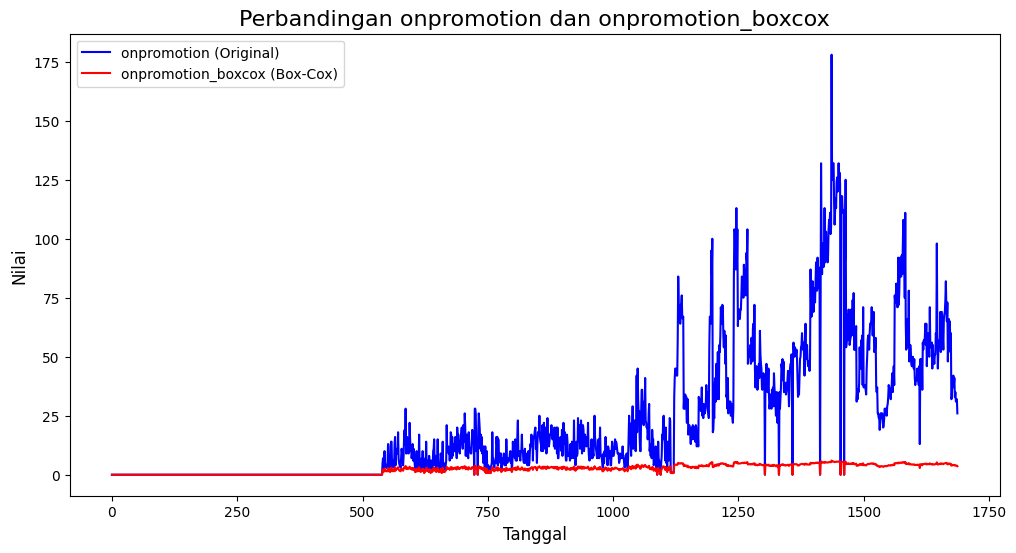

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot 'onpromotion' (data asli)
plt.plot(df_grocery_new.index, df_grocery_new['onpromotion'], label='onpromotion (Original)', color='blue')

# Plot 'onpromotion_boxcox' (setelah Box-Cox)
plt.plot(df_grocery_new.index, df_grocery_new['onpromotion_boxcox'], label='onpromotion_boxcox (Box-Cox)', color='red')

# Menambahkan label dan judul
plt.title('Perbandingan onpromotion dan onpromotion_boxcox', fontsize=16)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Nilai', fontsize=12)

# Menambahkan legenda
plt.legend()

# Menampilkan plot
plt.show()

In [ ]:
# Menghitung jumlah missing (NaN) per kolom
missing_per_column = df_grocery_new.isna().sum()
missing_per_column

,0
date,0
id,4
store_nbr,0
family,0
sales,0
onpromotion,0
dcoilwtico,525
onpromotion_boxcox,0


In [ ]:
# Buat rentang tanggal lengkap berdasarkan min & max
full_date_range = pd.date_range(start=df_grocery_new['date'].min(), end=df_grocery_new['date'].max(), freq='D')

# Cari tanggal yang hilang
missing_dates = full_date_range.difference(df_grocery_new['date'])
missing_dates

DatetimeIndex([], dtype='datetime64[ns]', freq='D')

In [ ]:
df_grocery_new

,date,id,store_nbr,family,sales,onpromotion,dcoilwtico,onpromotion_boxcox
0,2013-01-01,1464.0,5,GROCERY I,0.0,0.0,NaN,0.000000
1,2013-01-02,3246.0,5,GROCERY I,4558.0,0.0,93.14,0.000000
2,2013-01-03,5028.0,5,GROCERY I,3260.0,0.0,92.97,0.000000
3,2013-01-04,6810.0,5,GROCERY I,3085.0,0.0,93.12,0.000000
4,2013-01-05,8592.0,5,GROCERY I,3398.0,0.0,NaN,0.000000
...,...,...,...,...,...,...,...,...
1683,2017-08-11,2993442.0,5,GROCERY I,2864.0,35.0,48.81,3.968569
1684,2017-08-12,2995224.0,5,GROCERY I,2476.0,31.0,NaN,3.825072
1685,2017-08-13,2997006.0,5,GROCERY I,3141.0,31.0,NaN,3.825072
1686,2017-08-14,2998788.0,5,GROCERY I,2717.0,32.0,47.59,3.862470


In [ ]:
df_grocery_new['dcoilwtico_interpolate'] = (
    df_grocery_new['dcoilwtico']
    .interpolate(method='polynomial', order=2)
    .fillna(method='bfill')  # Mengisi NaN awal dengan nilai pertama yang valid
)

<ipython-input-79-0c56973c9553>:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method='bfill')  # Mengisi NaN awal dengan nilai pertama yang valid


In [ ]:
df_grocery_new

,date,id,store_nbr,family,sales,onpromotion,dcoilwtico,onpromotion_boxcox,dcoilwtico_interpolate
0,2013-01-01,1464.0,5,GROCERY I,0.0,0.0,NaN,0.000000,93.140000
1,2013-01-02,3246.0,5,GROCERY I,4558.0,0.0,93.14,0.000000,93.140000
2,2013-01-03,5028.0,5,GROCERY I,3260.0,0.0,92.97,0.000000,92.970000
3,2013-01-04,6810.0,5,GROCERY I,3085.0,0.0,93.12,0.000000,93.120000
4,2013-01-05,8592.0,5,GROCERY I,3398.0,0.0,NaN,0.000000,93.205338
...,...,...,...,...,...,...,...,...,...
1683,2017-08-11,2993442.0,5,GROCERY I,2864.0,35.0,48.81,3.968569,48.810000
1684,2017-08-12,2995224.0,5,GROCERY I,2476.0,31.0,NaN,3.825072,48.717426
1685,2017-08-13,2997006.0,5,GROCERY I,3141.0,31.0,NaN,3.825072,48.020802
1686,2017-08-14,2998788.0,5,GROCERY I,2717.0,32.0,47.59,3.862470,47.590000


#Modeling VARMAX

In [ ]:
from statsmodels.tsa.statespace.varmax import VARMAX
from sklearn.metrics import mean_absolute_error

# Pisahkan variabel endogen dan eksogen
endog = df_grocery_new[['sales', 'onpromotion_boxcox']]
exog = df_grocery_new[['dcoilwtico_interpolate']]

# Pisahkan data menjadi train dan test
train_size = int(len(df_grocery) * 0.8)
train_endog, test_endog = endog.iloc[:train_size], endog.iloc[train_size:]
train_exog, test_exog = exog.iloc[:train_size], exog.iloc[train_size:]

In [ ]:
train_endog

,sales,onpromotion_boxcox
date,,
2013-01-01,0.0,0.000000
2013-01-02,4558.0,0.000000
2013-01-03,3260.0,0.000000
2013-01-04,3085.0,0.000000
2013-01-05,3398.0,0.000000
...,...,...
2015-07-15,2865.0,1.684228
2015-07-16,2840.0,2.205411
2015-07-17,3482.0,2.924272


In [ ]:
test_endog

,sales,onpromotion_boxcox
930,3246.0,3.527375
931,2736.0,2.999520
932,2986.0,2.924272
933,2835.0,3.374826
934,2613.0,2.666188
...,...,...
1683,2864.0,3.968569
1684,2476.0,3.825072
1685,3141.0,3.825072
1686,2717.0,3.862470


In [ ]:
train_exog

,dcoilwtico_interpolate
0,93.140000
1,93.140000
2,92.970000
3,93.120000
4,93.205338
...,...
925,51.400000
926,50.900000
927,50.880000
928,50.564099


#Best VARMAX base on RMSE

In [ ]:
import itertools
import matplotlib.pyplot as plt

In [ ]:
from statsmodels.tsa.statespace.varmax import VARMAX
from sklearn.metrics import mean_squared_error
from scipy.special import inv_boxcox

# Grid search untuk parameter p dan q
p_options = range(1, 5)  # Order autoregressive
q_options = range(0, 4)  # Order moving average
lowest_error = float("inf")
best_parameters = None
optimal_model = None

# Hitung rata-rata aktual untuk normalisasi
avg_sales = test_endog['sales'].mean()
avg_promo = test_endog['onpromotion_boxcox'].mean()

# Coba semua kombinasi (p, q)
for p, q in itertools.product(p_options, q_options):
    try:
        print(f"Evaluating VARMAX({p},{q})...")

        # Train model VARMAX
        model_instance = VARMAX(train_endog, exog=train_exog, order=(p, q), trend='c')
        fitted_model = model_instance.fit(disp=False)

        # Forecast untuk data test
        predictions = fitted_model.forecast(steps=len(test_endog), exog=test_exog)

        # Kembalikan prediksi 'onpromotion' ke skala data awal
        predictions['onpromotion'] = inv_boxcox(predictions['onpromotion_boxcox'], lambda_bc) - 1  # Mengurangi 1 kembali
        test_endog['onpromotion'] = inv_boxcox(test_endog['onpromotion_boxcox'], lambda_bc) - 1  # Konversi actual juga

        # Hitung RMSE antara prediksi dan data aktual
        rmse_sales = np.sqrt(mean_squared_error(test_endog['sales'], predictions['sales']))
        rmse_promo = np.sqrt(mean_squared_error(test_endog['onpromotion'], predictions['onpromotion']))

        # Normalisasi RMSE
        rmse_sales_norm = rmse_sales / avg_sales
        rmse_promo_norm = rmse_promo / avg_promo
        rmse_total = rmse_sales_norm + rmse_promo_norm  # Gabungkan kesalahan yang telah dinormalisasi

        print(f"VARMAX({p},{q}) - Normalized RMSE: {rmse_total:.4f}")

        # Simpan model dengan RMSE terbaik
        if rmse_total < lowest_error:
            lowest_error = rmse_total
            best_parameters = (p, q)
            optimal_model = fitted_model

    except Exception as e:
        print(f"VARMAX({p},{q}) gagal dilatih: {e}")

print(f"\nBest VARMAX order: {best_parameters} dengan Normalized RMSE: {lowest_error:.4f}")

Evaluating VARMAX(1,0)...


<ipython-input-85-a25957bed8b3>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_endog['onpromotion'] = inv_boxcox(test_endog['onpromotion_boxcox'], lambda_bc) - 1  # Konversi actual juga
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'


VARMAX(1,0) - Normalized RMSE: 11.2205
Evaluating VARMAX(1,1)...


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
<ipython-input-85-a25957bed8b3>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.py

VARMAX(1,1) - Normalized RMSE: 10.9005
Evaluating VARMAX(1,2)...


...

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
<ipython-input-85-a25957bed8b3>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_endog['onpromotion'] = inv_boxcox(test_endog['onpromotion_boxcox'], lambda_bc) - 1  # Konversi actual juga
/usr/local/lib/python3.1

VARMAX(4,2) - Normalized RMSE: 11.3596
Evaluating VARMAX(4,3)...


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


VARMAX(4,3) - Normalized RMSE: 11.6247

Best VARMAX order: (1, 3) dengan Normalized RMSE: 10.7058


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
<ipython-input-85-a25957bed8b3>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_endog['onpromotion'] = inv_boxcox(test_endog['onpromotion_boxcox'], lambda_bc) - 1  # Konversi actual juga


In [ ]:
# Gunakan model terbaik untuk prediksi
test_preds1 = optimal_model.forecast(steps=len(test_endog), exog=test_exog)

# Kembalikan prediksi 'onpromotion' ke skala data awal untuk visualisasi
test_preds1['onpromotion'] = inv_boxcox(test_preds['onpromotion_boxcox'], lambda_bc) - 1

test_preds1


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'


,sales,onpromotion_boxcox,onpromotion
930,3693.759835,2.552192,9.863945
931,3398.862773,2.517339,9.537390
932,3383.146144,2.567513,10.010486
933,3400.696310,2.633507,10.663336
934,3410.355547,2.690780,11.259363
...,...,...,...
1683,3434.663213,3.006033,15.089449
1684,3435.034110,3.008141,15.118501
1685,3436.717646,3.014892,15.211884
1686,3438.535841,3.023719,15.334741


In [ ]:
# Hitung RMSE dari prediksi terbaik
final_rmse_sales = np.sqrt(mean_squared_error(test_endog['sales'], test_preds1['sales']))
final_rmse_promo = np.sqrt(mean_squared_error(test_endog['onpromotion'], test_preds1['onpromotion']))

print(f"Final RMSE Sales: {final_rmse_sales:.4f}")
print(f"Final RMSE Onpromotion: {final_rmse_promo:.4f}")

Final RMSE Sales: 785.5736
Final RMSE Onpromotion: 40.8586


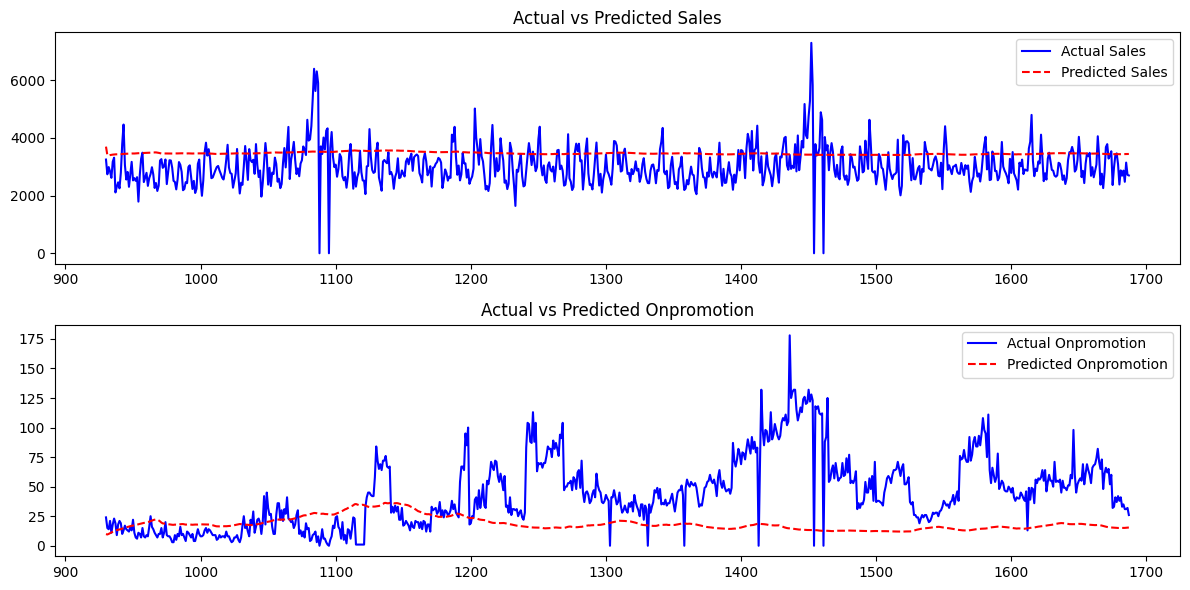

In [ ]:
# Plot hasil prediksi vs actual
plt.figure(figsize=(12, 6))

# Plot Sales
plt.subplot(2, 1, 1)
plt.plot(test_endog.index, test_endog['sales'], label='Actual Sales', color='blue')
plt.plot(test_endog.index, test_preds1['sales'], label='Predicted Sales', color='red', linestyle='dashed')
plt.title('Actual vs Predicted Sales')
plt.legend()

# Plot Onpromotion (sudah dalam skala asli)
plt.subplot(2, 1, 2)
plt.plot(test_endog.index, test_endog['onpromotion'], label='Actual Onpromotion', color='blue')
plt.plot(test_endog.index, test_preds1['onpromotion'], label='Predicted Onpromotion', color='red', linestyle='dashed')
plt.title('Actual vs Predicted Onpromotion')
plt.legend()

plt.tight_layout()
plt.show()

#Modeling LSTM

#Single Layer LSTM

In [ ]:
# Pastikan kolom tanggal dalam format datetime
df_grocery_new['date'] = pd.to_datetime(df_grocery_new['date'])

# Set kolom tanggal sebagai indeks
df_grocery_new.set_index('date', inplace=True)

# Pisahkan variabel endogen dan eksogen
endog = df_grocery_new[['sales', 'onpromotion_boxcox']]
exog = df_grocery_new[['dcoilwtico_interpolate']]

# Pisahkan data menjadi train dan test
train_size = int(len(df_grocery) * 0.8)
train_endog, test_endog = endog.iloc[:train_size], endog.iloc[train_size:]
train_exog, test_exog = exog.iloc[:train_size], exog.iloc[train_size:]

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import time
from sklearn.metrics import mean_squared_error

# Preprocessing
scaler_endog = MinMaxScaler()
scaler_exog = MinMaxScaler()

# Scaling the data (already done earlier)
endog_scaled = scaler_endog.fit_transform(endog)
exog_scaled = scaler_exog.fit_transform(exog)

In [ ]:
# Check the shape of the endog_scaled (should have 2 columns)
print(f"endog_scaled shape: {endog_scaled.shape}")

endog_scaled shape: (1688, 2)


In [ ]:
# Ensure endog_scaled has 2 columns (sales and onpromotion)
print(f"endog_scaled shape: {endog_scaled.shape}")  # (1688, 2)

# Combine exogenous (exog) and endogenous (endog) features into x
x = np.concatenate([exog_scaled, endog_scaled], axis=1)

# The target variable 'y' is the endog_scaled
y = endog_scaled  # 'sales' and 'onpromotion' as the target (2 columns)

endog_scaled shape: (1688, 2)


In [ ]:
def load_data(X, seq_len, train_size=0.9):
    amount_of_features = X.shape[1]
    X_mat = X
    sequence_length = seq_len + 1
    data = []

    for index in range(len(X_mat) - sequence_length):
        data.append(X_mat[index: index + sequence_length])

    data = np.array(data)
    train_split = int(round(train_size * data.shape[0]))
    train_data = data[:train_split, :]

    x_train = train_data[:, :-1]
    y_train = train_data[:, -1, 1:]  # Select only the last 2 columns (sales and onpromotion)

    x_test = data[train_split:, :-1]
    y_test = data[train_split:, -1, 1:]  # Select only the last 2 columns (sales and onpromotion)

    # Check shapes before reshaping
    print(f"x_train shape (before reshape): {x_train.shape}")
    print(f"y_train shape (before reshape): {y_train.shape}")

    # Make sure y_train and y_test have 2 columns (for 'sales' and 'onpromotion')
    assert y_train.shape[1] == 2, "y_train should have 2 columns (sales and onpromotion)"
    assert y_test.shape[1] == 2, "y_test should have 2 columns (sales and onpromotion)"

    # Reshape x_train and x_test to 3D arrays for LSTM input
    x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], amount_of_features))
    x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], amount_of_features))

    return x_train, y_train, x_test, y_test

# Setting window size
window = 22
X_train, y_train, X_test, y_test = load_data(x, window)

# Print the shapes of data after loading and reshaping
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

x_train shape (before reshape): (1498, 22, 3)
y_train shape (before reshape): (1498, 2)
X_train shape: (1498, 22, 3), y_train shape: (1498, 2)
X_test shape: (167, 22, 3), y_test shape: (167, 2)


In [ ]:
# LSTM Model
model = Sequential()
model.add(LSTM(units=50, input_shape=(window, X_train.shape[2])))
model.add(Dropout(0.2))

# Output layer with 2 units for 'sales' and 'onpromotion'
model.add(Dense(units=50, kernel_initializer='uniform', activation='tanh'))
model.add(Dense(units=2, kernel_initializer='uniform', activation='linear'))  # Two outputs

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Fit the model
start = time.time()
history = model.fit(X_train, y_train, epochs=100, batch_size=35, validation_split=0.05, verbose=1)
print('Compilation time: ', time.time() - start)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.1127 - val_loss: 0.0214
Epoch 2/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0149 - val_loss: 0.0252
Epoch 3/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0112 - val_loss: 0.0206
Epoch 4/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0099 - val_loss: 0.0205
Epoch 5/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0104 - val_loss: 0.0206
Epoch 6/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0102 - val_loss: 0.0217
Epoch 7/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0089 - val_loss: 0.0208
Epoch 8/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0092 - val_loss: 0.0207
Epoch 9/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0094 - val_loss: 0.0213
Epoch 10/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0099 - val_loss: 0.0207
Epoch 11/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0099 - val_loss: 0.0209
Epoch 12/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step

In [ ]:
# Predictions
trainPredict = model.predict(X_train)
testPredict = model.predict(X_test)

# Inverse transform to get the actual values
trainPredict = scaler_endog.inverse_transform(trainPredict)
trainY = scaler_endog.inverse_transform(y_train)
testPredict = scaler_endog.inverse_transform(testPredict)
testY = scaler_endog.inverse_transform(y_test)

# Plotting
plot_predicted_sales = testPredict[:, 0].reshape(-1, 1)
plot_predicted_onpromotion = testPredict[:, 1].reshape(-1, 1)

plot_actual_sales = testY[:, 0].reshape(-1, 1)
plot_actual_onpromotion = testY[:, 1].reshape(-1, 1)

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [ ]:
# Print shapes for verification
print(f"Plot actual sales shape: {plot_actual_sales.shape}")
print(f"Plot predicted sales shape: {plot_predicted_sales.shape}")

Plot actual sales shape: (167, 1)
Plot predicted sales shape: (167, 1)


In [ ]:
# Calculate RMSE for both sales and onpromotion
trainScore_sales = mean_squared_error(trainY[:, 0], trainPredict[:, 0]) ** 0.5
testScore_sales = mean_squared_error(testY[:, 0], plot_predicted_sales[:, 0]) ** 0.5

trainScore_onpromotion = mean_squared_error(trainY[:, 1], trainPredict[:, 1]) ** 0.5
testScore_onpromotion = mean_squared_error(testY[:, 1], plot_predicted_onpromotion[:, 0]) ** 0.5

In [ ]:
print(f'Train Score for sales: {trainScore_sales:.2f} RMSE')
print(f'Test Score for sales: {testScore_sales:.2f} RMSE')

print(f'Train Score for onpromotion: {trainScore_onpromotion:.2f} RMSE')
print(f'Test Score for onpromotion: {testScore_onpromotion:.2f} RMSE')

Train Score for sales: 669.10 RMSE
Test Score for sales: 465.53 RMSE
Train Score for onpromotion: 0.53 RMSE
Test Score for onpromotion: 0.33 RMSE


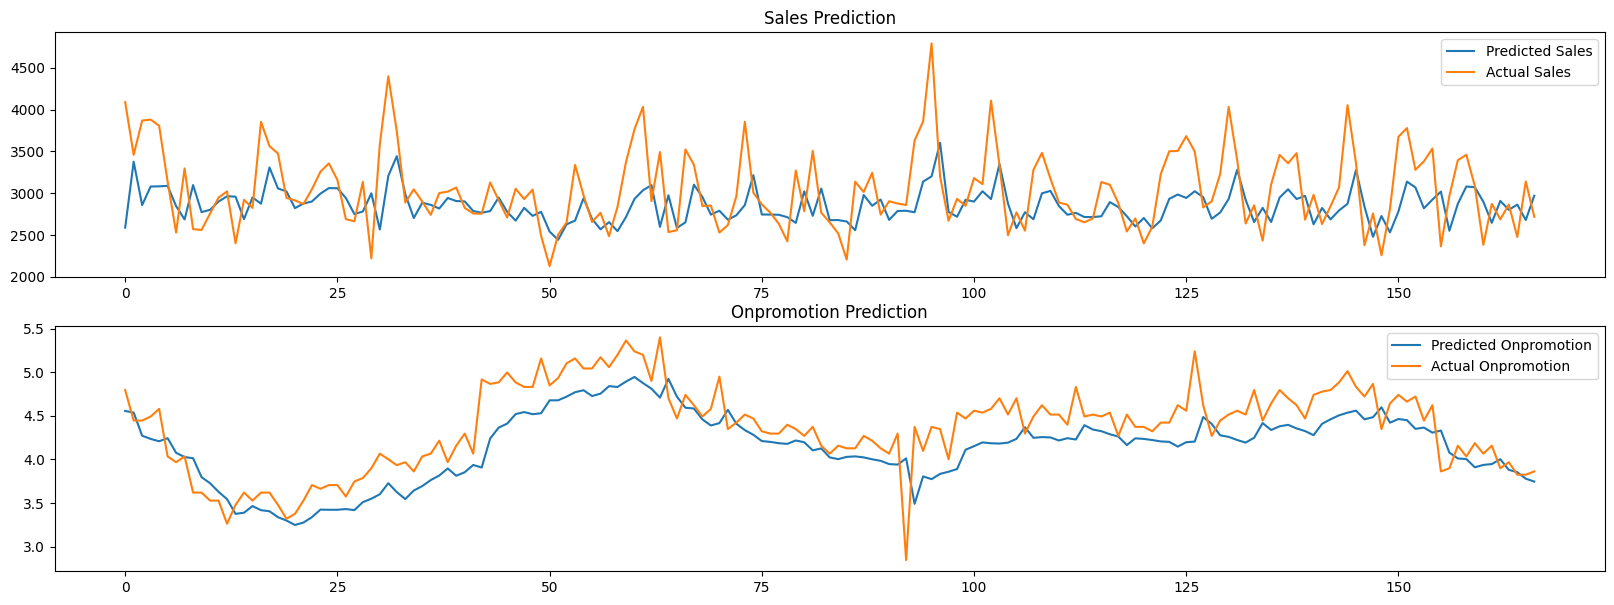

In [ ]:
# Plot the results for both targets
plt.figure(figsize=(20, 7))

# Sales plot
plt.subplot(2, 1, 1)
plt.plot(pd.DataFrame(plot_predicted_sales), label='Predicted Sales')
plt.plot(pd.DataFrame(plot_actual_sales), label='Actual Sales')
plt.legend(loc='best')
plt.title('Sales Prediction')

# Onpromotion plot
plt.subplot(2, 1, 2)
plt.plot(pd.DataFrame(plot_predicted_onpromotion), label='Predicted Onpromotion')
plt.plot(pd.DataFrame(plot_actual_onpromotion), label='Actual Onpromotion')
plt.legend(loc='best')
plt.title('Onpromotion Prediction')

plt.show()

#Stacked LSTM Using Dropout

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Stacked LSTM Model with Dropout
model2 = Sequential()

# First LSTM layer
model2.add(LSTM(units=50, return_sequences=True, input_shape=(window, X_train.shape[2])))
model2.add(Dropout(0.2))

# Second LSTM layer
model2.add(LSTM(units=50, return_sequences=True))
model2.add(Dropout(0.2))

# Third LSTM layer
model2.add(LSTM(units=50))
model2.add(Dropout(0.2))

# Dense layers
model2.add(Dense(units=50, kernel_initializer='uniform', activation='tanh'))
model2.add(Dense(units=2, kernel_initializer='uniform', activation='linear'))  # Two outputs (sales and onpromotion)

earlystop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=50)
callbacks_list = [earlystop]

# Compile the model
model2.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
start = time.time()
history2 = model2.fit(X_train, y_train, epochs=100, batch_size=35, validation_split=0.05, verbose=1)
print('Training time: ', time.time() - start)

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


41/41 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - loss: 0.1157 - val_loss: 0.0378
Epoch 2/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0174 - val_loss: 0.0214
Epoch 3/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0113 - val_loss: 0.0207
Epoch 4/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0123 - val_loss: 0.0214
Epoch 5/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 0.0128 - val_loss: 0.0221
Epoch 6/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0107 - val_loss: 0.0206
Epoch 7/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0120 - val_loss: 0.0207
Epoch 8/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0115 - val_loss: 0.0210
Epoch 9/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0107 - val_loss: 0.0207
Epoch 10/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 0.0111 - val_loss: 0.0210
Epoch 11/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 0.0113 - val_loss: 0.0222
Epoch 12/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0

In [ ]:
# Predictions
trainPredict2 = model2.predict(X_train)
testPredict2 = model2.predict(X_test)

# Inverse transform to get actual values
trainPredict2 = scaler_endog.inverse_transform(trainPredict2)
trainY2 = scaler_endog.inverse_transform(y_train)
testPredict2 = scaler_endog.inverse_transform(testPredict2)
testY2 = scaler_endog.inverse_transform(y_test)

47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [ ]:
# Calculate RMSE for both sales and onpromotion
trainScore_sales2 = mean_squared_error(trainY2[:, 0], trainPredict2[:, 0]) ** 0.5
testScore_sales2 = mean_squared_error(testY2[:, 0], testPredict2[:, 0]) ** 0.5

trainScore_onpromotion2 = mean_squared_error(trainY2[:, 1], trainPredict2[:, 1]) ** 0.5
testScore_onpromotion2 = mean_squared_error(testY2[:, 1], testPredict2[:, 1]) ** 0.5

In [ ]:
print(f'Train Score for sales: {trainScore_sales2:.2f} RMSE')
print(f'Test Score for sales: {testScore_sales2:.2f} RMSE')

print(f'Train Score for onpromotion: {trainScore_onpromotion2:.2f} RMSE')
print(f'Test Score for onpromotion: {testScore_onpromotion2:.2f} RMSE')

Train Score for sales: 693.48 RMSE
Test Score for sales: 475.02 RMSE
Train Score for onpromotion: 0.49 RMSE
Test Score for onpromotion: 0.30 RMSE


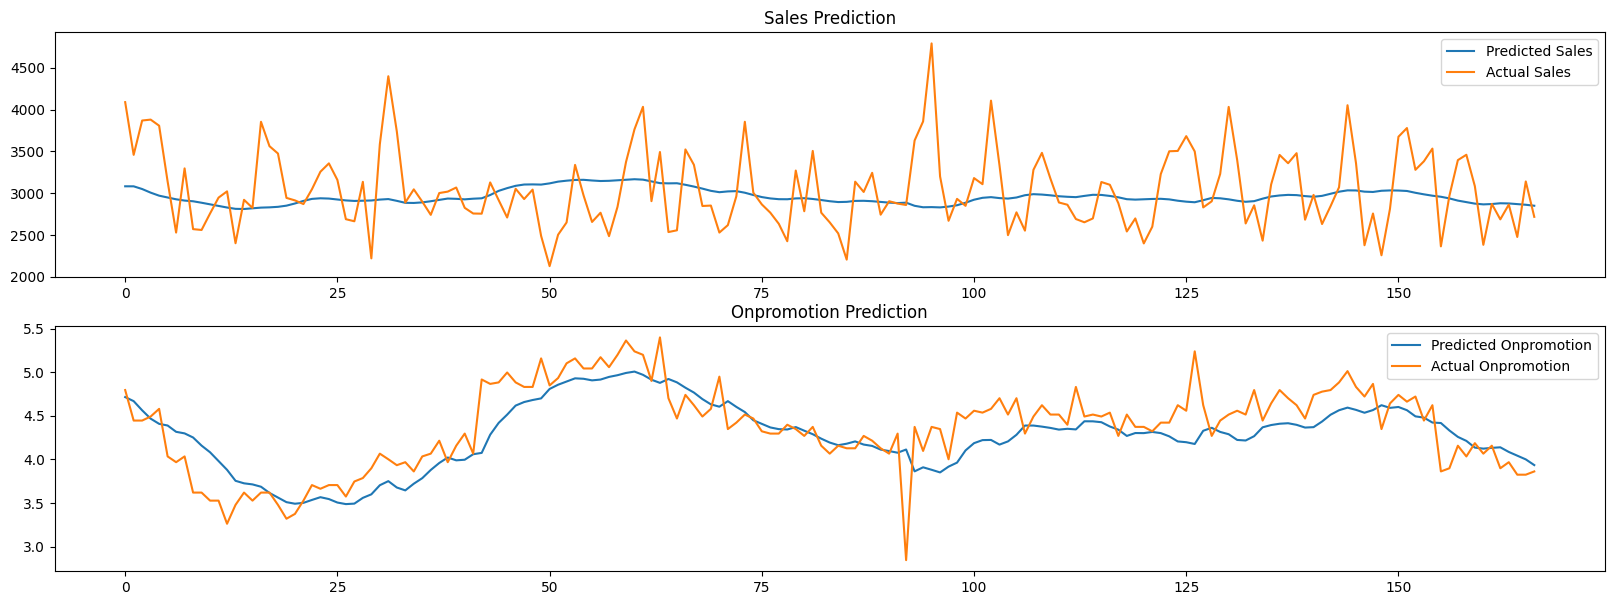

In [ ]:
# Plot the results
plt.figure(figsize=(20, 7))

# Sales plot
plt.subplot(2, 1, 1)
plt.plot(pd.DataFrame(testPredict2[:, 0]), label='Predicted Sales')
plt.plot(pd.DataFrame(testY2[:, 0]), label='Actual Sales')
plt.legend(loc='best')
plt.title('Sales Prediction')

# Onpromotion plot
plt.subplot(2, 1, 2)
plt.plot(pd.DataFrame(testPredict2[:, 1]), label='Predicted Onpromotion')
plt.plot(pd.DataFrame(testY2[:, 1]), label='Actual Onpromotion')
plt.legend(loc='best')
plt.title('Onpromotion Prediction')

plt.show()

#Evaluasi Model

In [ ]:
rmse_comparison = {
    "Model": ["VARMAX", "VARMAX", "Single Layer LSTM", "Single Layer LSTM", "Stacked LSTM", "Stacked LSTM"],
    "Metric": ["Test RMSE (Sales)", "Test RMSE (Onpromotion)", "Test RMSE (Sales)", "Test RMSE (Onpromotion)", "Test RMSE (Sales)", "Test RMSE (Onpromotion)"],
    "RMSE Value": [
        final_rmse_sales, final_rmse_promo, testScore_sales, testScore_onpromotion, testScore_sales2, testScore_onpromotion2
    ]
}

# Membuat DataFrame untuk perbandingan
rmse_df = pd.DataFrame(rmse_comparison)
rmse_df

,Model,Metric,RMSE Value
0,VARMAX,Test RMSE (Sales),785.573565
1,VARMAX,Test RMSE (Onpromotion),40.858626
2,Single Layer LSTM,Test RMSE (Sales),465.532769
3,Single Layer LSTM,Test RMSE (Onpromotion),0.334708
4,Stacked LSTM,Test RMSE (Sales),475.016447
5,Stacked LSTM,Test RMSE (Onpromotion),0.299023
